In [1]:
import sys
import socket

print(f"Node:{socket.gethostname()}")


Node:c073.curta.zedat.fu-berlin.de


In [2]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["POLARS_MAX_THREADS"] = "8"


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from pathlib import Path
import duckdb

from scipy.stats import skew, spearmanr

from photometry.models.hapke import HapkeModel
from photometry.core.types import GeometryBatch
from photometry.fitting.least_sq import LeastSquaresFitter


# Set scientific plotting style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)


import os

print(os.getcwd())

/home/kaushim07/photometry_mcmc_env


In [3]:


# Set up paths and load phase-curve data for all phases

project_root = Path.cwd().resolve()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent


# Load the RC Parquet file

#parquet_path = project_root / "data" / "06_silver_layer" / "combined_rc_survey_sample_corrected.parquet"

#parquet_path_dsk256 = project_root / "data" / "silver/dsk256" / "combined_rc_survey_sample_corrected_dsk256.parquet"

#parquet_path_survey_dsk256 = project_root / "data" / "silver/dsk256" / "survey_dsk256.parquet"

parquet_path_survey_ellipsoid = project_root / "data" / "06_silver_layer_ellipsoid" / "survey_ellipsoid.parquet"

parquet_path_survey_dsk256_110825 = project_root / "data" / "silver/dsk256" / "survey_dsk256_110825.parquet"




## Ellipsoid

In [4]:
files_ellipsoid = duckdb.sql("""
    SELECT image_id, COUNT(*) AS n
    FROM read_parquet('data/geometry/ellipsoid/survey/*.parquet')
    GROUP BY image_id
""").df()


print(f"Distinct images: {len(files_ellipsoid)}")

# Filter code is in the filename — F1B vs F1C/D/F
# image_id format: FC21B..._...F1B etc. Check the filter substring.


print(files_ellipsoid['image_id'].str[-3:].value_counts())

Distinct images: 816
image_id
F1B    816
Name: count, dtype: int64


In [16]:
files_ellipsoid

,image_id,n
0,FC21B0004925_11229141826F1B,667169
1,FC21B0004977_11229183827F1B,642088
2,FC21B0004995_11229200826F1B,644953
3,FC21B0005650_11232170557F1B,743436
4,FC21B0006163_11235100728F1B,1048576
...,...,...
811,FC21B0006147_11235084728F1B,1048576
812,FC21B0006372_11238055914F1B,640536
813,FC21B0006500_11238192214F1B,650696
814,FC21B0006572_11239043544F1B,769272


In [13]:
duckdb.sql("PRAGMA threads=8;")
duckdb.sql("PRAGMA memory_limit='28GB';")


db_ellipsoid = 'data/geometry/ellipsoid/survey/*.parquet'

print("Executing High-Speed DuckDB Audit...\n")

# --- 1. Boundary & Triangle Law Checks ---


print("--- 1. Boundary & Physics Audit ---")


ellipsoid_audit_df = duckdb.sql(f"""
                      
SELECT 
    COUNT(*) AS total_pixels,
    SUM(CASE WHEN incidence < 0 OR emission < 0 OR phase < 0 
               OR incidence > 90 OR emission > 90 OR phase > 180 
               OR iof <= 0 OR iof > 1.5 THEN 1 ELSE 0 END) AS boundary_violations,
    SUM(CASE WHEN phase < ABS(incidence - emission) 
               OR phase > (incidence + emission) + 0.1 THEN 1 ELSE 0 END) AS triangle_violations
FROM read_parquet('{db_ellipsoid}')

""").df()

display(ellipsoid_audit_df)

# --- 2. Global Distribution Statistics ---


print("\n--- 2. Global Photometric Statistics ---")


ellipsoid_stats_df = duckdb.sql(f"""
                      
SELECT 
    mission_phase,
    COUNT(*) AS total_pixels,
    ROUND(MIN(iof), 4) AS min_iof,
    ROUND(AVG(iof), 4) AS mean_iof,
    ROUND(MAX(iof), 4) AS max_iof,
    ROUND(MIN(phase), 2) AS min_phase_deg,
    ROUND(MAX(phase), 2) AS max_phase_deg
FROM read_parquet('{db_ellipsoid}')
GROUP BY mission_phase
ORDER BY mission_phase

""").df()

display(ellipsoid_stats_df)

# --- 3. MLE Histogram Binning for Seaborn/Matplotlib ---

print("\n--- 3. Aggregating Distribution for Plotting ---")
# Instead of pulling 670M rows, we group I/F into bins of 0.005 width

ellipsoid_hist_df = duckdb.sql(f"""
SELECT 
    ROUND(iof * 200) / 200 AS iof_bin,
    COUNT(*) AS pixel_count
FROM read_parquet('{db_ellipsoid}')
GROUP BY 1
ORDER BY 1
""").df()

print("Plotting results...")
plt.figure(figsize=(12, 6))

# Plot the pre-aggregated data as a bar chart (visually identical to a histogram)
sns.barplot(
    data=ellipsoid_hist_df[ellipsoid_hist_df['iof_bin'] <= 0.25], # Zoom in on the main distribution
    x='iof_bin', 
    y='pixel_count', 
    color='purple',
    width=1.0,
    alpha=0.3
)

# Clean up the X-axis ticks so they aren't crowded
plt.xticks(rotation=45)
ax = plt.gca()
for ind, label in enumerate(ax.get_xticklabels()):
    if ind % 10 == 0:  # Show every 10th label
        label.set_visible(True)
    else:
        label.set_visible(False)

plt.title("I/F Reflectance Distribution")
plt.xlabel("I/F (Binned to 0.005)")
plt.ylabel("Pixel Count")
plt.tight_layout()
plt.show()

Executing High-Speed DuckDB Audit...

--- 1. Boundary & Physics Audit ---


,total_pixels,boundary_violations,triangle_violations
0,679710522,25671419.0,13973.0



--- 2. Global Photometric Statistics ---


BinderException: Binder Error: Referenced column "mission_phase" not found in FROM clause!
Candidate bindings: "emission", "iof", "incidence", "longitude"

In [9]:
os.environ["POLARS_MAX_THREADS"] = "4"

print(f"Polars initialized. Threadpool size: {pl.thread_pool_size()}")


# print(f"Loading Silver Layer: {parquet_path.name}...\n")

df_approach_ellipsoid = pl.scan_parquet(parquet_path)  # lazy load with Polars

display(df_approach_ellipsoid.collect_schema().names())
# Quick verification that the math columns survived
# print(f"Loaded {len(df_approach_ellipsoid):,} pixels.")
# display(df_approach_ellipsoid)

stats_ellipsoid = (
    df_approach_ellipsoid.select(
        [
            pl.all().exclude(["image_id", "mission_phase"])  # Exclude IDs/Strings for math
        ]
    )
    .collect()
    .describe()
)

display(stats_ellipsoid)


# Group by mission phase to see the geometric "split"

phase_stats_ellipsoid = (
    df_approach_ellipsoid.group_by("mission_phase")
    .agg(
        [
            pl.len().alias("pixel_count"),
            pl.col("phase").min().alias("min_phase"),
            pl.col("phase").max().alias("max_phase"),
            pl.col("iof").mean().alias("avg_iof"),
            pl.col("iof").std().alias("std_iof"),
        ]
    )
    .collect()
)

display(phase_stats_ellipsoid)


# Check the 1st and 99th percentiles for I/F
outliers_ellipsoid = df_approach_ellipsoid.select(
    [
        pl.col("iof").quantile(0.01).alias("1st_percentile"),
        pl.col("iof").quantile(0.99).alias("99th_percentile"),
        pl.col("iof").max().alias("absolute_max"),
    ]
).collect()

print("I/F Outlier Check:")
display(outliers_ellipsoid)

Polars initialized. Threadpool size: 4


['image_id',
 'mission_phase',
 'pixel_x',
 'pixel_y',
 'iof',
 'incidence',
 'emission',
 'phase',
 'latitude',
 'longitude',
 'mean_phase']

statistic,pixel_x,pixel_y,iof,incidence,emission,phase,latitude,longitude,mean_phase
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",7.306932e6,7.306932e6,7.306932e6,7.306932e6,7.306932e6,7.306932e6,7.306932e6,7.306932e6,7.306932e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",507.638247,474.18928,0.08834,42.675335,32.844772,42.881107,-20.079145,-3.983533,42.881107
"""std""",241.984313,279.882889,0.037624,18.547535,17.399572,20.964954,31.429646,103.461617,20.925407
"""min""",0.0,0.0,0.01,0.009256,0.020516,4.870608,-89.95929,-179.999969,7.712799
"""25%""",328.0,238.0,0.060692,28.556055,19.409088,26.228128,-45.322983,-93.246712,26.261381
"""50%""",507.0,461.0,0.086722,42.384018,30.259544,40.630493,-19.079138,-7.161118,40.537727
"""75%""",687.0,699.0,0.115083,56.80888,44.366909,59.306396,5.62981,84.368736,59.497002
"""max""",1023.0,1023.0,0.238661,79.999992,79.999992,97.739754,79.906212,179.999985,97.138927


mission_phase,pixel_count,min_phase,max_phase,avg_iof,std_iof
str,u32,f32,f32,f32,f32
"""SURVEY""",6578928,7.971255,97.739754,0.084984,0.034624
"""RC""",728004,4.870608,83.401245,0.118666,0.048508


I/F Outlier Check:


1st_percentile,99th_percentile,absolute_max
f32,f32,f32
0.014569,0.171907,0.238661


In [4]:
import duckdb

# Connect to the file directly
con = duckdb.connect()
# This doesn't load the data; it just creates a pointer
preview = con.execute(f"SELECT * FROM read_parquet('{parquet_path}') LIMIT 15").df()

display(preview)

,image_id,mission_phase,pixel_x,pixel_y,iof,incidence,emission,phase,latitude,longitude,mean_phase
0,FC21B0004965_11229173826F1B,SURVEY,558,43,0.083917,27.879816,27.789867,53.991085,0.137033,-43.822422,54.167039
1,FC21B0004965_11229173826F1B,SURVEY,668,43,0.092935,36.910381,18.839294,53.403332,5.939615,-45.784092,54.167039
2,FC21B0004965_11229173826F1B,SURVEY,675,43,0.091413,37.461433,18.318439,53.365936,6.297713,-45.901497,54.167039
3,FC21B0004965_11229173826F1B,SURVEY,813,43,0.096001,47.838055,10.116112,52.628868,13.217777,-48.110401,54.167039
4,FC21B0004965_11229173826F1B,SURVEY,173,44,0.056836,19.252682,75.066147,56.047672,-31.381668,-28.882980,54.167039
5,FC21B0004965_11229173826F1B,SURVEY,186,44,0.071621,16.491657,72.155289,55.978268,-29.127756,-30.365896,54.167039
6,FC21B0004965_11229173826F1B,SURVEY,244,44,0.056846,7.628112,62.124458,55.668568,-21.806154,-34.565311,54.167039
7,FC21B0004965_11229173826F1B,SURVEY,329,44,0.058104,6.824183,50.911209,55.214542,-14.290185,-38.153217,54.167039
8,FC21B0004965_11229173826F1B,SURVEY,575,44,0.082450,29.342476,26.330042,53.900070,1.074763,-44.093155,54.167039
9,FC21B0004965_11229173826F1B,SURVEY,713,44,0.092852,40.424728,15.642938,53.162758,8.240117,-46.477093,54.167039


In [5]:
# Only load what the Hapke model and the binning logic care about
cols = ["mission_phase", "iof", "incidence", "emission", "phase", "image_id", "mean_phase"]

df_approach = pd.read_parquet(parquet_path, columns=cols)

print(f"Loaded {len(df_approach):,} pixels with reduced memory footprint.")
# Use .head() to avoid the browser hanging while trying to render the display
display(df_approach)

Loaded 7,306,932 pixels with reduced memory footprint.


,mission_phase,iof,incidence,emission,phase,image_id,mean_phase
0,SURVEY,0.083917,27.879816,27.789867,53.991085,FC21B0004965_11229173826F1B,54.167039
1,SURVEY,0.092935,36.910381,18.839294,53.403332,FC21B0004965_11229173826F1B,54.167039
2,SURVEY,0.091413,37.461433,18.318439,53.365936,FC21B0004965_11229173826F1B,54.167039
3,SURVEY,0.096001,47.838055,10.116112,52.628868,FC21B0004965_11229173826F1B,54.167039
4,SURVEY,0.056836,19.252682,75.066147,56.047672,FC21B0004965_11229173826F1B,54.167039
...,...,...,...,...,...,...,...
7306927,SURVEY,0.125959,70.322502,56.134670,25.864304,FC21B0006448_11238133517F1B,26.493705
7306928,SURVEY,0.016908,42.380692,40.693893,28.264416,FC21B0006448_11238133517F1B,26.493705
7306929,SURVEY,0.065329,48.354607,41.827229,27.652605,FC21B0006448_11238133517F1B,26.493705
7306930,SURVEY,0.063212,50.284145,42.567318,27.471689,FC21B0006448_11238133517F1B,26.493705


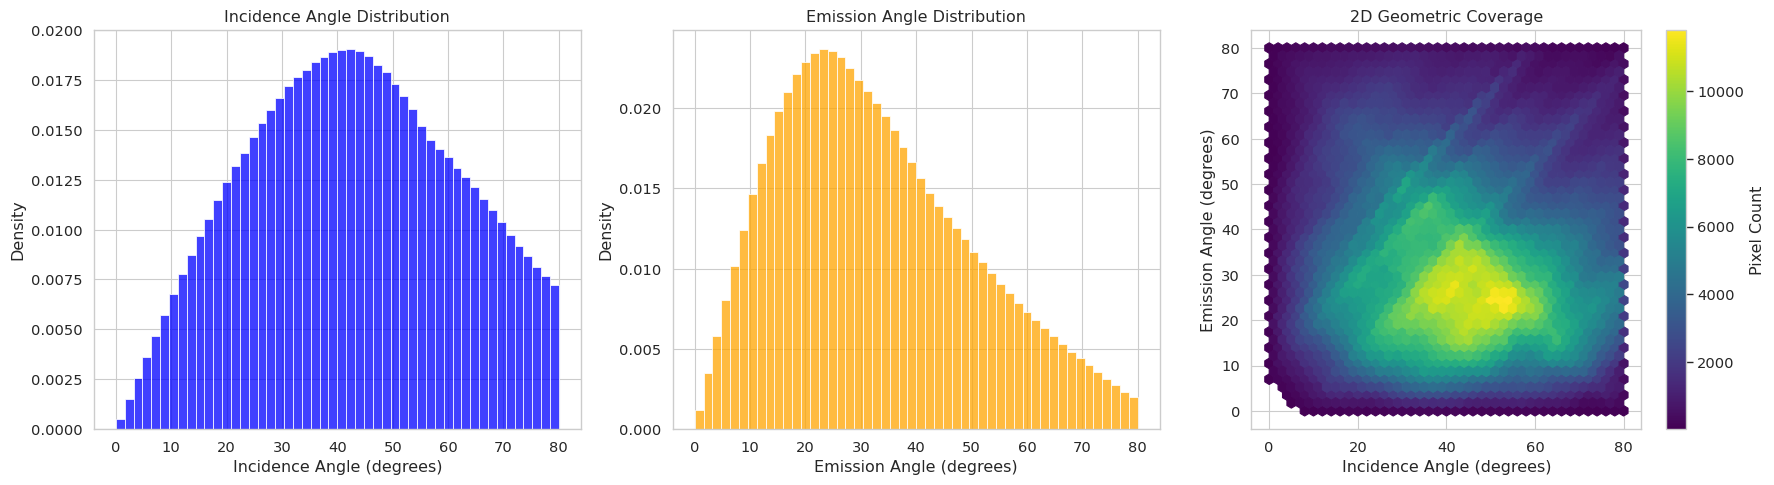

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Incidence Distribution
sns.histplot(df_approach["incidence"], bins=50, ax=axes[0], color="blue", stat="density")
axes[0].set_title("Incidence Angle Distribution")
axes[0].set_xlabel("Incidence Angle (degrees)")

# 2. Emission Distribution
sns.histplot(df_approach["emission"], bins=50, ax=axes[1], color="orange", stat="density")
axes[1].set_title("Emission Angle Distribution")
axes[1].set_xlabel("Emission Angle (degrees)")

# 3. 2D Phase Space Coverage
hb = axes[2].hexbin(
    df_approach["incidence"], df_approach["emission"], gridsize=40, cmap="viridis", mincnt=1
)
axes[2].set_title("2D Geometric Coverage")
axes[2].set_xlabel("Incidence Angle (degrees)")
axes[2].set_ylabel("Emission Angle (degrees)")
cb = fig.colorbar(hb, ax=axes[2], label="Pixel Count")

plt.tight_layout()
plt.show()

I/F Mean:   0.0883
I/F Median: 0.0867
I/F Skew:   0.1653 (Positive = Right-tailed)
----------------------------------------


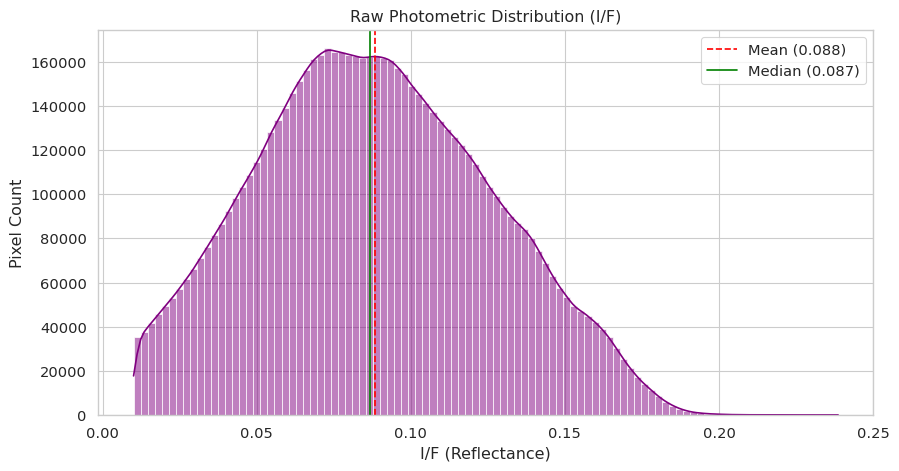

In [7]:
# Calculate Summary Statistics
iof_mean = df_approach["iof"].mean()
iof_median = df_approach["iof"].median()
iof_skew = skew(df_approach["iof"].dropna())

print(f"I/F Mean:   {iof_mean:.4f}")
print(f"I/F Median: {iof_median:.4f}")
print(f"I/F Skew:   {iof_skew:.4f} (Positive = Right-tailed)")
print("-" * 40)

# Plot the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_approach["iof"], bins=100, kde=True, color="purple")
plt.axvline(iof_mean, color="red", linestyle="--", label=f"Mean ({iof_mean:.3f})")
plt.axvline(iof_median, color="green", linestyle="-", label=f"Median ({iof_median:.3f})")

plt.title("Raw Photometric Distribution (I/F)")
plt.xlabel("I/F (Reflectance)")
plt.ylabel("Pixel Count")
plt.legend()
plt.show()

Spearman Correlation (ρ): -0.7993
----------------------------------------


/localscratch/tmp/kaushim07/tmp.25689279.0/ipykernel_360947/619187750.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


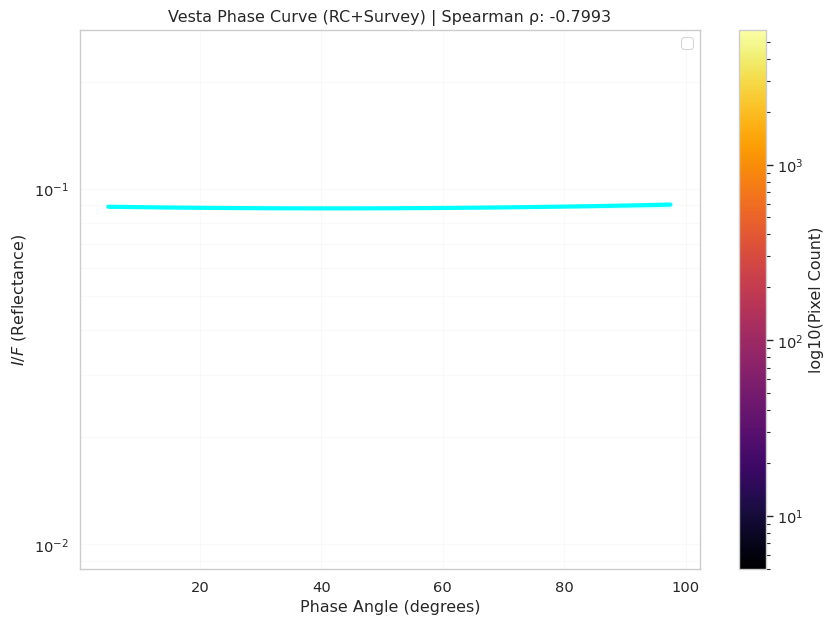

In [8]:
# Calculate Spearman Correlation
rho, p_val = spearmanr(df_approach["phase"], df_approach["iof"])

print(f"Spearman Correlation (ρ): {rho:.4f}")
print("-" * 40)

# 1. Plotting the Phase Curve
plt.figure(figsize=(10, 7))

# Hexbin shows the density of the 7.3M pixels (log scale to see the tail)
hb = plt.hexbin(
    df_approach["phase"], df_approach["iof"], gridsize=100, cmap="inferno", mincnt=5, bins="log"
)

# 2. Use a Polynomial fit instead of LOWESS (doesn't need statsmodels)
sns.regplot(
    x=df_approach["phase"].sample(50000),
    y=df_approach["iof"].sample(50000),
    scatter=False,
    color="cyan",
    order=2,  # A 2nd-order polynomial fits the phase curve well
    line_kws={"linewidth": 3, "label": "Global Trend (2nd Order Poly)"},
)

# 3. OVERLAY: Plot the Gold Cubes to see the 'Discretized' truth
# This shows how well your 5x5x5 binning represents the raw data
#sns.scatterplot(
   # data=df_gold,
   # x="phase_bin",
   # y="mean_iof",
   # color="white",
   # s=20,
   # edgecolor="black",
   # alpha=0.8,
   # label="Binned Gold Cubes",
#)

plt.title(f"Vesta Phase Curve (RC+Survey) | Spearman ρ: {rho:.4f}")
plt.xlabel("Phase Angle (degrees)")
plt.ylabel("$I/F$ (Reflectance)")
plt.yscale("log")
plt.colorbar(hb, label="log10(Pixel Count)")
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.legend()
plt.show()

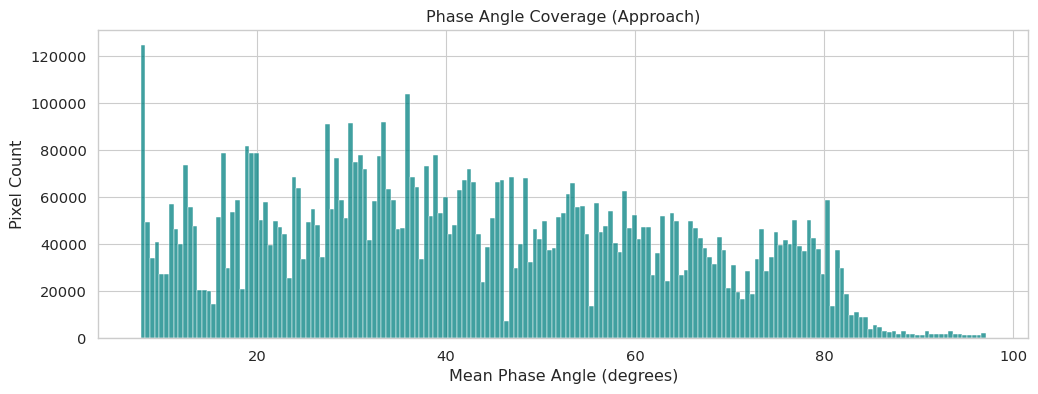

Sample Pixel Counts per 5-Degree Phase Bin:
mean_phase
(10, 15]    401435
(15, 20]    536657
(20, 25]    480486
(25, 30]    595237
(30, 35]    696054
(35, 40]    619062
(40, 45]    537831
(45, 50]    445194
(50, 55]    525726
(55, 60]    452920
(60, 65]    413451
(65, 70]    381612
(70, 75]    287173
dtype: int64


In [9]:
plt.figure(figsize=(12, 4))

# Plot Phase Angle with fine bins (0.5 degrees)
sns.histplot(df_approach["mean_phase"], binwidth=0.5, color="teal")

plt.title("Phase Angle Coverage (Approach)")
plt.xlabel("Mean Phase Angle (degrees)")
plt.ylabel("Pixel Count")
plt.show()

# Show exact counts for a few critical 2-degree slices
bins = pd.cut(df_approach["mean_phase"], bins=np.arange(10, 80, 5))
bin_counts = df_approach.groupby(bins, observed=False).size()

print("Sample Pixel Counts per 5-Degree Phase Bin:")
print(bin_counts[bin_counts > 0])

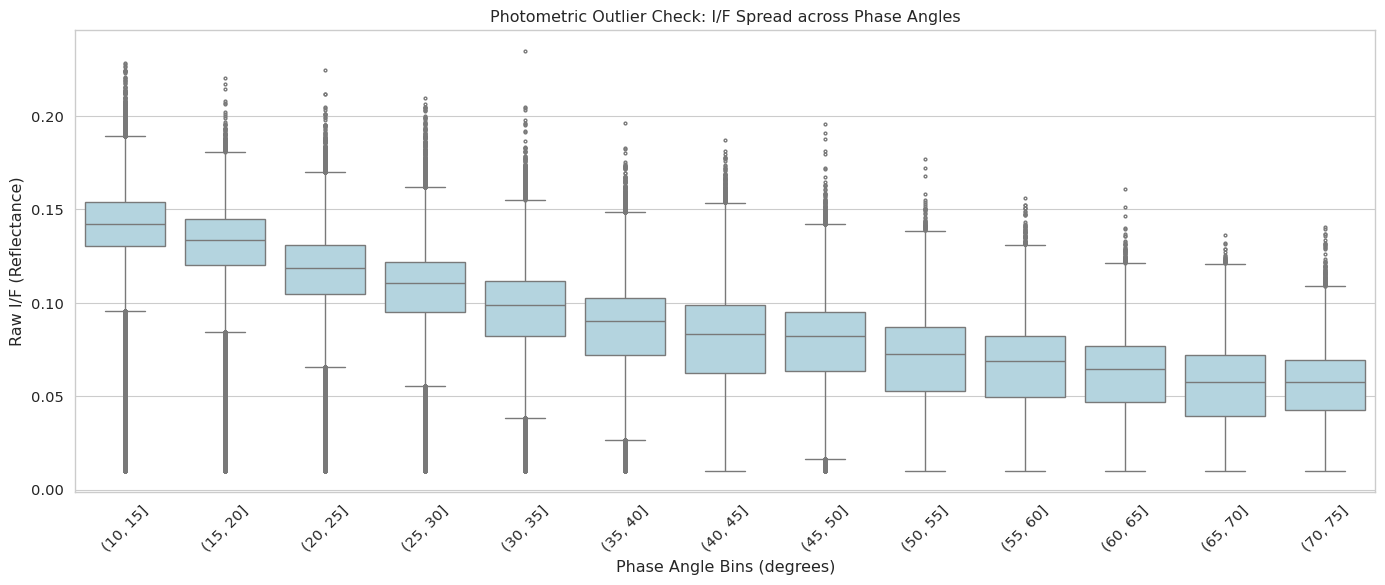

In [10]:
# Create 2-degree bins for the x-axis
df_approach["phase_bin"] = pd.cut(df_approach["mean_phase"], bins=np.arange(10, 80, 5))

plt.figure(figsize=(14, 6))
# Draw the boxplot to hunt for outliers
sns.boxplot(x="phase_bin", y="iof", data=df_approach, color="lightblue", fliersize=2)

plt.title("Photometric Outlier Check: I/F Spread across Phase Angles")
plt.xlabel("Phase Angle Bins (degrees)")
plt.ylabel("Raw I/F (Reflectance)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Slice: 20° to 22° Phase
Local Spearman Correlation (I/F vs Geometric Term): 0.4355
----------------------------------------


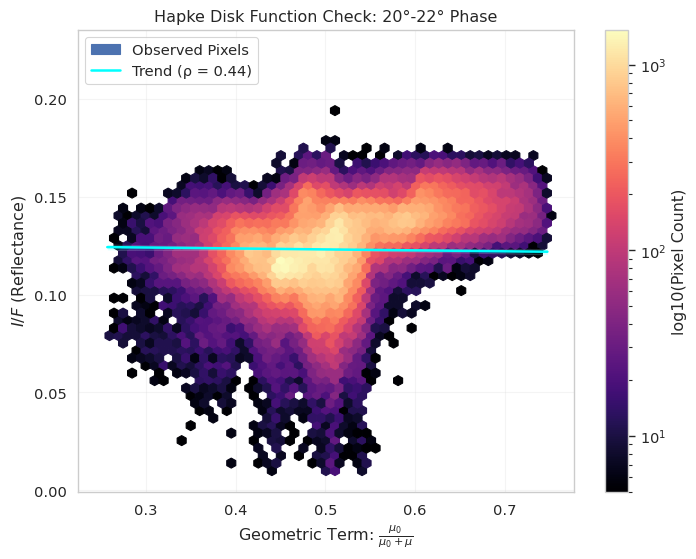

In [11]:
df_approach["mu0"] = np.cos(np.radians(df_approach["incidence"]))
df_approach["mu"] = np.cos(np.radians(df_approach["emission"]))

# 2. Define the Hapke-Standard X-axis (Geometric Term)
# At a constant phase, I/F should be proportional to this term
df_approach["ls_term"] = df_approach["mu0"] / (df_approach["mu0"] + df_approach["mu"])

# 3. Isolate the slice
phase_min, phase_max = 20, 22
slice_mask = (df_approach["phase"] > phase_min) & (df_approach["phase"] <= phase_max)
df_slice = df_approach[slice_mask]

# 4. Local Correlation (Checking how well the Disk Function explains the data)
rho_local, _ = spearmanr(df_slice["ls_term"], df_slice["iof"])

print(f"Slice: {phase_min}° to {phase_max}° Phase")
print(f"Local Spearman Correlation (I/F vs Geometric Term): {rho_local:.4f}")
print("-" * 40)

# 5. The Plot
plt.figure(figsize=(8, 6))

# 1. Add a label to the hexbin
hb = plt.hexbin(
    df_slice["ls_term"],
    df_slice["iof"],
    gridsize=50,
    cmap="magma",
    mincnt=5,
    bins="log",
    label="Observed Pixels",
)

# 2. Move 'label' out of line_kws to ensure Matplotlib sees it
sns.regplot(
    x=df_slice["ls_term"].sample(10000),
    y=df_slice["iof"].sample(10000),
    scatter=False,
    color="cyan",
    label=f"Trend (ρ = {rho_local:.2f})",
)

plt.title(f"Hapke Disk Function Check: {phase_min}°-{phase_max}° Phase")
plt.xlabel(r"Geometric Term: $\frac{\mu_0}{\mu_0 + \mu}$")
plt.ylabel("$I/F$ (Reflectance)")

# 3. This will now work without the 'garbage' warning
plt.legend(loc="upper left")

plt.colorbar(hb, label="log10(Pixel Count)")
plt.grid(True, alpha=0.2)
plt.show()

In [10]:
df_approach.columns

Index(['alpha_grid', 'i_grid', 'e_grid', 'mean_incidence', 'mean_emission',
       'mean_phase', 'mean_iof', 'std_iof', 'n_pixels'],
      dtype='object')

In [12]:
grid_size = 5.0



# Creating the Grid Coordinates
df_approach["i_grid"] = np.floor(df_approach["incidence"] / grid_size) * grid_size
df_approach["e_grid"] = np.floor(df_approach["emission"] / grid_size) * grid_size
df_approach["alpha_grid"] = np.floor(df_approach["phase"] / grid_size) * grid_size


df_approach = (
    df_approach.groupby(["alpha_grid", "i_grid", "e_grid"])
    .agg(
        mean_incidence=("incidence", "mean"),
        mean_emission=("emission", "mean"),
        mean_phase=("phase", "mean"),
        mean_iof=("iof", "mean"),
        std_iof=("iof", "std"),  
        n_pixels=("iof", "count"),
    )
    .reset_index()
)


df_approach = df_approach[df_approach["n_pixels"] >= 50].copy()


df_approach["std_iof"] = df_approach["std_iof"].fillna(df_approach["mean_iof"] * 0.01)
df_approach.loc[df_approach["std_iof"] == 0, "std_iof"] = df_approach["mean_iof"] * 0.01

# Drop the extreme limbs and terminators where the Ellipsoid model fails completely

df_approach_clean = df_approach[(df_approach["mean_incidence"] <= 80.0) & (df_approach["mean_emission"] <= 80.0)].copy()

print(f"Removed extreme geometry. Retained {len(df_approach_clean)} safe cubes.")
display(df_approach_clean)

Removed extreme geometry. Retained 2390 safe cubes.


,alpha_grid,i_grid,e_grid,mean_incidence,mean_emission,mean_phase,mean_iof,std_iof,n_pixels
0,0.0,70.0,65.0,73.574814,68.654449,4.979819,0.158257,0.006449,75
2,0.0,75.0,70.0,77.543884,72.712875,4.946836,0.162161,0.006987,215
4,5.0,0.0,0.0,4.361635,4.320911,8.344124,0.161401,0.010463,123
5,5.0,0.0,5.0,2.956946,7.721089,8.709504,0.161805,0.010632,1117
6,5.0,0.0,10.0,3.623826,11.728083,8.973080,0.162360,0.010560,846
...,...,...,...,...,...,...,...,...,...
2499,95.0,35.0,65.0,36.309830,66.735680,96.270317,0.053875,0.007494,144
2501,95.0,40.0,50.0,43.072506,53.214428,95.852318,0.058922,0.005332,678
2502,95.0,40.0,55.0,41.155556,56.438404,96.104332,0.060111,0.006988,473
2504,95.0,45.0,45.0,47.210873,48.471947,95.456253,0.062169,0.007033,335


In [ ]:
# 1. Geometry Ingestion (Strictly Radians, using the safe shielded dataset)
geom_clean = GeometryBatch(
    incidence=np.deg2rad(df_approach_clean['mean_incidence'].values),
    emission=np.deg2rad(df_approach_clean['mean_emission'].values),
    phase=np.deg2rad(df_approach_clean['mean_phase'].values)
)
measured_iof = df_approach_clean['mean_iof'].values

# 2. Architecturally Correct Heteroskedastic Weighting
weights_inv_sigma = 1.0 / df_approach_clean['std_iof'].values #weights_inv_var = 1.0 / (df_approach_clean['std_iof'].values ** 2)

# 3. Instantiate Architecture (2-Parameter Ellipsoid-Safe Mode)

model = HapkeModel(enable_shoe=False, enable_roughness=False) 
fitter = LeastSquaresFitter()

# 4. Multi-Start Generator (2D Space)
n_starts = 100
np.random.seed(42)
initial_guesses = [
    {
        "w": np.random.uniform(0.15, 0.40),
        "g": np.random.uniform(-0.5, -0.1)
    }
    for _ in range(n_starts)
]

print(f"Model initialized in 2-Parameter mode.")
print(f"Parameters to fit: {model.parameter_names()}")

Model initialized in 2-Parameter mode.
Parameters to fit: ['w', 'g']


In [14]:
print("Executing 2-PARAMETER Architectural Fit...")
best_cost = np.inf
best_result = None

for guess in initial_guesses:
    model.parameters.update(guess)
    
    result = fitter.fit(
        model=model,
        geometry=geom_clean,
        observed_reflectance=measured_iof,
        weights=weights_inv_sigma
    )
    
    if result.metadata["success"] and result.objective_value < best_cost:
        best_cost = result.objective_value
        best_result = result

    if best_result is None:
        raise RuntimeError("All 100 multi-start optimization runs failed to converge.")

print("\n=== 2-PARAMETER FIT RESULTS ===")
print(f"Cost: {best_result.objective_value:.4f}")



for param_name, value in best_result.fitted_parameters.items():
    print(f"{param_name}: {value:.4f}")

print("\n=== PARAMETER UNCERTAINTIES (1-Sigma) ===")
if best_result.metadata.get("parameter_errors"):
    for param_name, error in best_result.metadata["parameter_errors"].items():
        print(f"{param_name}: +/- {error:.4f}")
else:
    print("Jacobian failed to invert.")

Executing 2-PARAMETER Architectural Fit...

=== 2-PARAMETER FIT RESULTS ===
Cost: 22.6735
w: 0.2994
g: -0.3879

=== PARAMETER UNCERTAINTIES (1-Sigma) ===
w: +/- 0.0017
g: +/- 0.0028


=== 2-PARAMETER FIT RMS ===
Overall Fractional (Relative) RMS Error: 27.39%


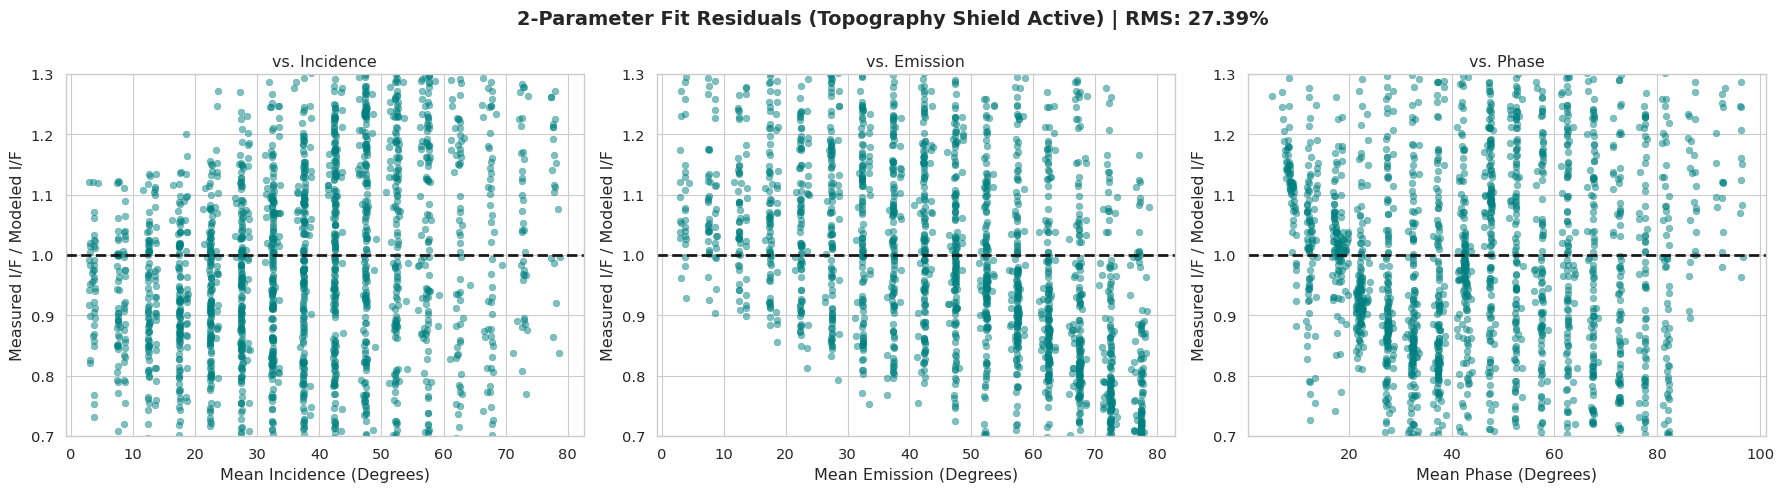

In [ ]:
model.parameters.update(best_result.fitted_parameters)

# 2. Predict the Theoretical I/F
df_approach_clean['modeled_iof'] = model._reflectance_numpy(geom_clean)

# 3. Calculate Ratio and Overall RMS
df_approach_clean['ratio'] = df_approach_clean['mean_iof'] / df_approach_clean['modeled_iof']
rms_error = np.sqrt(np.mean(((df_approach_clean['mean_iof'] - df_approach_clean['modeled_iof']) / df_approach_clean['mean_iof'])**2))

print(f"=== 2-PARAMETER FIT RMS ===")  # noqa: F541
print(f"Overall Fractional (Relative) RMS Error: {rms_error*100:.2f}%")

# 4. Plot the Residuals
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'2-Parameter Fit Residuals (Topography Shield Active) | RMS: {rms_error*100:.2f}%', fontsize=14, fontweight='bold')

sns.scatterplot(x=df_approach_clean['mean_incidence'], y=df_approach_clean['ratio'], ax=axes[0], alpha=0.5, color='teal', edgecolor=None)
axes[0].set_title('vs. Incidence')
axes[0].axhline(1.0, color='k', ls='--', lw=2)
axes[0].set_xlabel('Mean Incidence (Degrees)')

sns.scatterplot(x=df_approach_clean['mean_emission'], y=df_approach_clean['ratio'], ax=axes[1], alpha=0.5, color='teal', edgecolor=None)
axes[1].set_title('vs. Emission')
axes[1].axhline(1.0, color='k', ls='--', lw=2)
axes[1].set_xlabel('Mean Emission (Degrees)')

sns.scatterplot(x=df_approach_clean['mean_phase'], y=df_approach_clean['ratio'], ax=axes[2], alpha=0.5, color='teal', edgecolor=None)
axes[2].set_title('vs. Phase')
axes[2].axhline(1.0, color='k', ls='--', lw=2)
axes[2].set_xlabel('Mean Phase (Degrees)')

for ax in axes:
    ax.set_ylim(0.7, 1.3)
    ax.set_ylabel('Measured I/F / Modeled I/F')

plt.tight_layout()
plt.show()

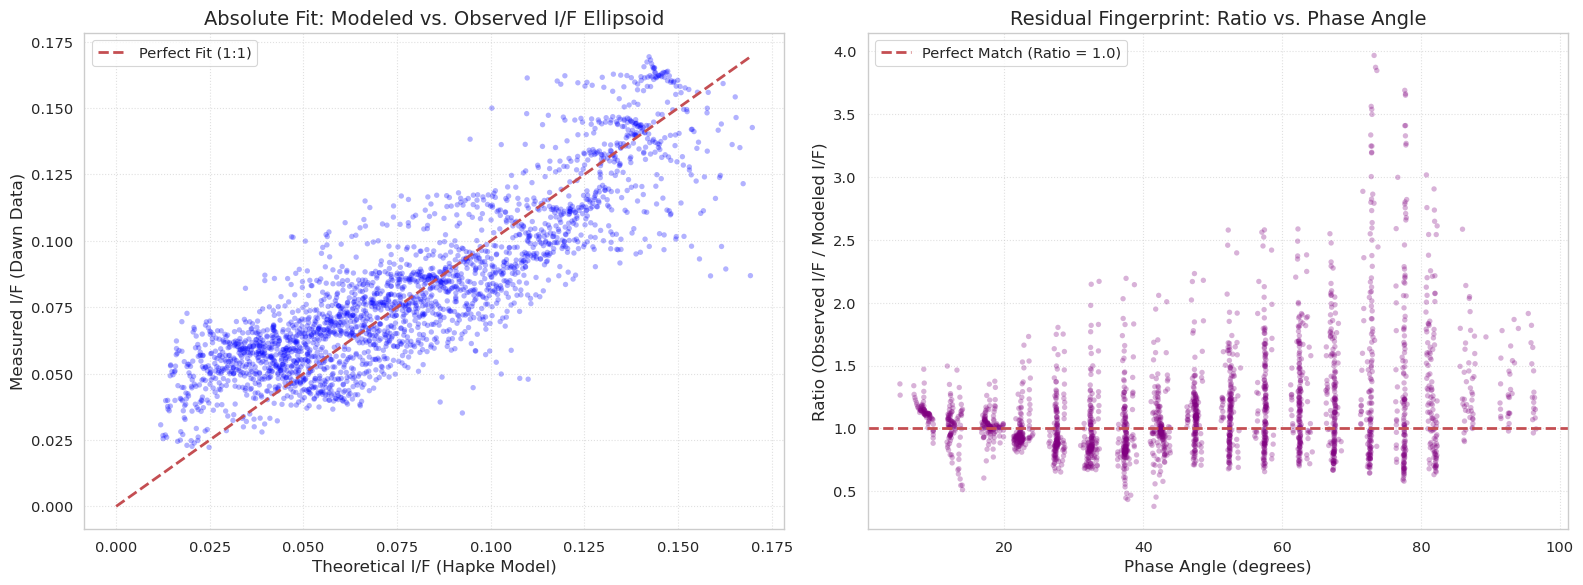

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
#  Observed vs. Modeled (1:1 Line)
# ==========================================
sns.scatterplot(
    x='modeled_iof', 
    y='mean_iof', 
    data=df_approach_clean, 
    ax=axes[0], 
    alpha=0.3, 
    color='blue',
    s=15,
    edgecolor='none'
)

# Plot the red 1:1 perfect fit line
max_val = max(df_approach_clean['mean_iof'].max(), df_approach_clean['modeled_iof'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label="Perfect Fit (1:1)")

axes[0].set_title('Absolute Fit: Modeled vs. Observed I/F Ellipsoid', fontsize=14)
axes[0].set_xlabel('Theoretical I/F (Hapke Model)', fontsize=12)
axes[0].set_ylabel('Measured I/F (Dawn Data)', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)


 #==========================================
#  The Physical Fingerprint (Ratio vs. Phase)
# ==========================================
sns.scatterplot(
    x='mean_phase', 
    y='ratio', 
    data=df_approach_clean, 
    ax=axes[1], 
    alpha=0.3, 
    color='purple',
    s=15,
    edgecolor='none'
)

# Plot the ideal ratio line at 1.0
axes[1].axhline(1.0, color='r', linestyle='--', lw=2, label="Perfect Match (Ratio = 1.0)")

axes[1].set_title('Residual Fingerprint: Ratio vs. Phase Angle', fontsize=14)
axes[1].set_xlabel('Phase Angle (degrees)', fontsize=12)
axes[1].set_ylabel('Ratio (Observed I/F / Modeled I/F)', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#

## Gaskell DSK256

In [ ]:

files = duckdb.sql("""
    SELECT image_id, COUNT(*) AS n
    FROM read_parquet('data/04_geometry_tables_fast/survey/*.parquet')
    GROUP BY image_id
""").df()


print(f"Distinct images: {len(files)}")

# Filter code is in the filename — F1B vs F1C/D/F
# image_id format: FC21B..._...F1B etc. Check the filter substring.


print(files['image_id'].str[-3:].value_counts())

Distinct images: 1153
image_id
F1B    845
F1C    164
F1F     72
F1D     72
Name: count, dtype: int64


In [5]:
files = duckdb.sql("""
    SELECT image_id, COUNT(*) AS n
    FROM read_parquet('data/geometry/dsk256/survey/*.parquet')
    GROUP BY image_id
""").df()


print(f"Distinct images: {len(files)}")

# Filter code is in the filename — F1B vs F1C/D/F
# image_id format: FC21B..._...F1B etc. Check the filter substring.


print(files['image_id'].str[-3:].value_counts())

Distinct images: 845
image_id
F1B    845
Name: count, dtype: int64


Executing High-Speed DuckDB Audit...

--- 1. Boundary & Physics Audit ---


,total_pixels,boundary_violations,triangle_violations
0,454233549,0.0,10162.0



--- 2. Global Photometric Statistics ---


,mission_phase,total_pixels,min_iof,mean_iof,max_iof,min_phase_deg,max_phase_deg
0,survey,454233549,0.0027,0.1373,0.4805,9.67,97.919998



--- 3. Aggregating Distribution for Plotting ---
Plotting results...


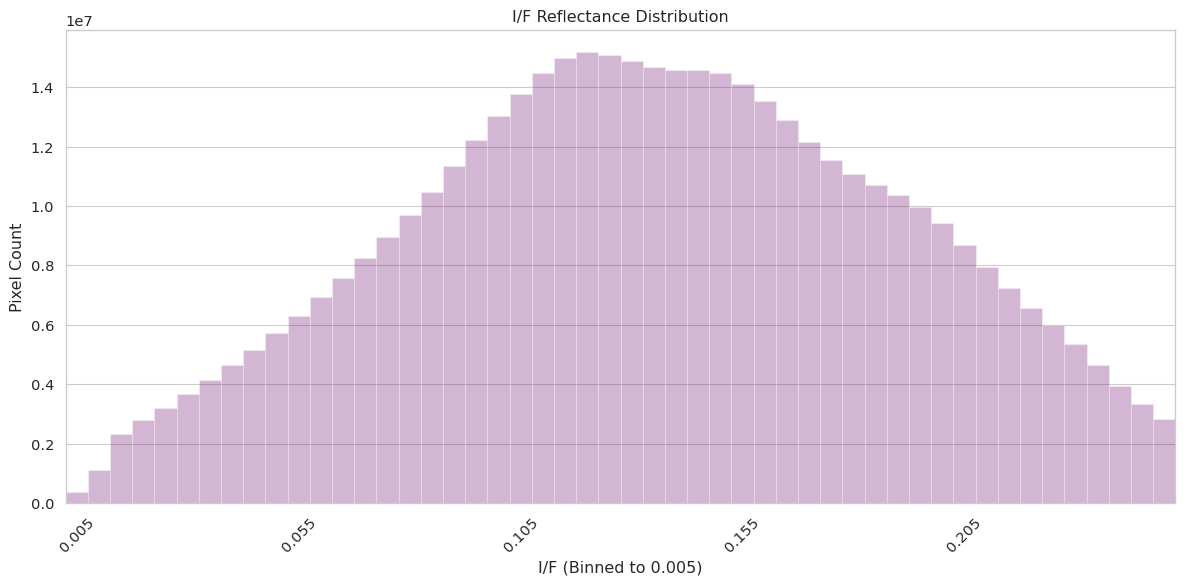

In [6]:
duckdb.sql("PRAGMA threads=8;")
duckdb.sql("PRAGMA memory_limit='28GB';")

#db = 'data/silver/dsk256/survey_dsk256.parquet'

db_110825 = 'data/silver/dsk256/survey_dsk256_110825.parquet'

print("Executing High-Speed DuckDB Audit...\n")

# --- 1. Boundary & Triangle Law Checks ---


print("--- 1. Boundary & Physics Audit ---")


audit_df = duckdb.sql(f"""
                      
SELECT 
    COUNT(*) AS total_pixels,
    SUM(CASE WHEN incidence < 0 OR emission < 0 OR phase < 0 
               OR incidence > 90 OR emission > 90 OR phase > 180 
               OR iof <= 0 OR iof > 1.5 THEN 1 ELSE 0 END) AS boundary_violations,
    SUM(CASE WHEN phase < ABS(incidence - emission) 
               OR phase > (incidence + emission) + 0.1 THEN 1 ELSE 0 END) AS triangle_violations
FROM read_parquet('{db_110825}')

""").df()

display(audit_df)

# --- 2. Global Distribution Statistics ---


print("\n--- 2. Global Photometric Statistics ---")


stats_df = duckdb.sql(f"""
                      
SELECT 
    mission_phase,
    COUNT(*) AS total_pixels,
    ROUND(MIN(iof), 4) AS min_iof,
    ROUND(AVG(iof), 4) AS mean_iof,
    ROUND(MAX(iof), 4) AS max_iof,
    ROUND(MIN(phase), 2) AS min_phase_deg,
    ROUND(MAX(phase), 2) AS max_phase_deg
FROM read_parquet('{db_110825}')
GROUP BY mission_phase
ORDER BY mission_phase

""").df()

display(stats_df)

# --- 3. MLE Histogram Binning for Seaborn/Matplotlib ---

print("\n--- 3. Aggregating Distribution for Plotting ---")
# Instead of pulling 670M rows, we group I/F into bins of 0.005 width

hist_df = duckdb.sql(f"""
SELECT 
    ROUND(iof * 200) / 200 AS iof_bin,
    COUNT(*) AS pixel_count
FROM read_parquet('{db_110825}')
GROUP BY 1
ORDER BY 1
""").df()

print("Plotting results...")
plt.figure(figsize=(12, 6))

# Plot the pre-aggregated data as a bar chart (visually identical to a histogram)
sns.barplot(
    data=hist_df[hist_df['iof_bin'] <= 0.25], # Zoom in on the main distribution
    x='iof_bin', 
    y='pixel_count', 
    color='purple',
    width=1.0,
    alpha=0.3
)

# Clean up the X-axis ticks so they aren't crowded
plt.xticks(rotation=45)
ax = plt.gca()
for ind, label in enumerate(ax.get_xticklabels()):
    if ind % 10 == 0:  # Show every 10th label
        label.set_visible(True)
    else:
        label.set_visible(False)

plt.title("I/F Reflectance Distribution")
plt.xlabel("I/F (Binned to 0.005)")
plt.ylabel("Pixel Count")
plt.tight_layout()
plt.show()

In [7]:
check = duckdb.sql(f"""
    SELECT
        COUNT(*)                                   AS n_rows,
        COUNT(DISTINCT image_id)                   AS n_images,
        
        -- Incidence Range
        MIN(incidence)                             AS min_incidence,
        MAX(incidence)                             AS max_incidence,
        
        -- Emission Range
        MIN(emission)                              AS min_emission,
        MAX(emission)                              AS max_emission,
        
        -- Phase Range
        MIN(phase)                                 AS min_phase,
        MAX(phase)                                 AS max_phase,
        
        -- Reflectance (I/F) Range
        MIN(iof)                                   AS min_iof,
        MAX(iof)                                   AS max_iof,
        
        -- Sanity Check
        SUM(CASE WHEN image_id NOT LIKE '%F1B%' THEN 1 ELSE 0 END) AS non_F1B_rows
    FROM read_parquet('{db_110825}')
""").df()

display(check)

,n_rows,n_images,min_incidence,max_incidence,min_emission,max_emission,min_phase,max_phase,min_iof,max_iof,non_F1B_rows
0,454233549,816,0.006339,79.999992,0.000417,79.999992,9.671019,97.923813,0.00271,0.480508,0.0


I/F Mean:   0.1373
I/F Median: 0.1362
I/F Skew:   0.0388 (Positive = Right-tailed)
----------------------------------------


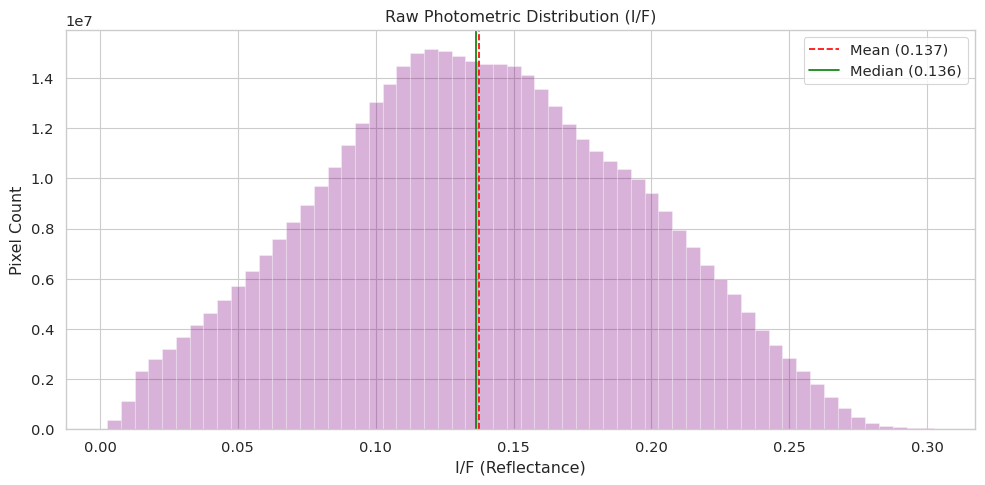

In [8]:
stats_df = duckdb.sql(f"""
SELECT 
    AVG(iof) AS iof_mean,
    QUANTILE_CONT(iof, 0.5) AS iof_median,
    SKEWNESS(iof) AS iof_skew
FROM read_parquet('{db_110825}')
""").df()

iof_mean_dsk = stats_df['iof_mean'][0]
iof_median_dsk = stats_df['iof_median'][0]
iof_skew_dsk = stats_df['iof_skew'][0]

print(f"I/F Mean:   {iof_mean_dsk:.4f}")
print(f"I/F Median: {iof_median_dsk:.4f}")
print(f"I/F Skew:   {iof_skew_dsk:.4f} (Positive = Right-tailed)")
print("-" * 40)

# 2. Pre-aggregate the Histogram Bins (Width = 0.005)
hist_df = duckdb.sql(f"""
SELECT 
    ROUND(iof * 200) / 200 AS iof_bin,
    COUNT(*) AS count
FROM read_parquet('{db_110825}')
GROUP BY 1
ORDER BY 1
""").df()

# 3. Plotting the Aggregated Data (Zero RAM Impact)
plt.figure(figsize=(10, 5))

# Filter extreme long-tail outliers just for a cleaner plot (e.g., I/F <= 0.3)
plot_df = hist_df[hist_df['iof_bin'] <= 0.3]

# A bar plot of pre-binned data looks identical to sns.histplot
plt.bar(plot_df['iof_bin'], plot_df['count'], width=0.005, color="purple", alpha=0.3)

plt.axvline(iof_mean_dsk, color="red", linestyle="--", label=f"Mean ({iof_mean_dsk:.3f})")
plt.axvline(iof_median_dsk, color="green", linestyle="-", label=f"Median ({iof_median_dsk:.3f})")

plt.title("Raw Photometric Distribution (I/F)")
plt.xlabel("I/F (Reflectance)")
plt.ylabel("Pixel Count")
plt.legend()
plt.tight_layout()
plt.show()

## Binning phase curves for i,e <50 

In [9]:
# Maximize the 32GB SLURM node
duckdb.sql("PRAGMA threads=8;")
duckdb.sql("PRAGMA memory_limit='28GB';")


# Paths

golden_path = Path("data/golden/survey_binned_dsk256_110825_range50.parquet")
golden_path.parent.mkdir(parents=True, exist_ok=True)


binned_dsk256_lt50_query = f"""

SELECT 
    -- 1. Banker's Rounding with Float-Safe Epsilon (< 1e-9)

    (CASE 
        WHEN ABS((phase/5.0) - FLOOR(phase/5.0) - 0.5) < 1e-9
        THEN (CASE WHEN CAST(FLOOR(phase/5.0) AS BIGINT) % 2 = 0 
              THEN FLOOR(phase/5.0) ELSE CEIL(phase/5.0) END)
        ELSE ROUND(phase/5.0) 
    END) * 5.0 AS alpha_grid,
    
    (CASE 
        WHEN ABS((incidence/5.0) - FLOOR(incidence/5.0) - 0.5) < 1e-9
        THEN (CASE WHEN CAST(FLOOR(incidence/5.0) AS BIGINT) % 2 = 0 
              THEN FLOOR(incidence/5.0) ELSE CEIL(incidence/5.0) END)
        ELSE ROUND(incidence/5.0) 
    END) * 5.0 AS i_grid,
    
    (CASE 
        WHEN ABS((emission/5.0) - FLOOR(emission/5.0) - 0.5) < 1e-9
        THEN (CASE WHEN CAST(FLOOR(emission/5.0) AS BIGINT) % 2 = 0 
              THEN FLOOR(emission/5.0) ELSE CEIL(emission/5.0) END)
        ELSE ROUND(emission/5.0) 
    END) * 5.0 AS e_grid,
    
    -- 2. Target Aggregations

    AVG(incidence) AS mean_incidence,
    AVG(emission) AS mean_emission,
    AVG(phase) AS mean_phase,
    AVG(iof) AS mean_iof,
    STDDEV_SAMP(iof) AS std_iof,
    COUNT(*) AS n_pixels

FROM read_parquet('{db_110825}')

-- 3. The Physical Boundary Restored (Triangle Law)

WHERE incidence < 50.0
  AND emission < 50.0
  -- AND iof > 0.01
  AND image_id LIKE '%F1B%'
  AND phase >= ABS(incidence - emission)       
  AND phase <= (incidence + emission) + 0.1

GROUP BY 1, 2, 3

-- 4. Statistical Validity Check

HAVING COUNT(*) >= 10 
   AND STDDEV_SAMP(iof) IS NOT NULL

ORDER BY 1, 2, 3

"""


# Execute the query and pull the tiny result table into Python RAM

df_binned_dsk256_lt50 = duckdb.sql(binned_dsk256_lt50_query).df()

print(f"DuckDB binning complete. Retained {len(df_binned_dsk256_lt50):,} safe geometric cubes.")

# Save the GL so you never have to do this again

df_binned_dsk256_lt50.to_parquet(golden_path, index=False)
print(f"Saved GL to: {golden_path}")
display(df_binned_dsk256_lt50.head())



DuckDB binning complete. Retained 1,010 safe geometric cubes.
Saved GL to: data/golden/survey_binned_dsk256_110825_range50.parquet


,alpha_grid,i_grid,e_grid,mean_incidence,mean_emission,mean_phase,mean_iof,std_iof,n_pixels
0,10.0,0.0,10.0,1.837609,11.182477,11.886826,0.220191,0.009045,87
1,10.0,5.0,5.0,6.466508,6.284393,12.008304,0.252055,0.022495,1696
2,10.0,5.0,10.0,4.936697,9.244856,11.987473,0.250911,0.023160,2623
3,10.0,5.0,15.0,6.167619,13.887558,12.098957,0.262079,0.026583,594
4,10.0,10.0,0.0,11.164462,1.526839,11.858164,0.249032,0.019109,3255


## Binning phase curves for i,e <80 

In [10]:
# Maximize the 32GB SLURM node
duckdb.sql("PRAGMA threads=8;")
duckdb.sql("PRAGMA memory_limit='28GB';")


# Paths

golden_path = Path("data/golden/survey_binned_dsk256_110825_range80.parquet")
golden_path.parent.mkdir(parents=True, exist_ok=True)


binned_dsk256_lt80_query = f"""

SELECT 
    -- 1. Banker's Rounding with Float-Safe Epsilon (< 1e-9)

    (CASE 
        WHEN ABS((phase/5.0) - FLOOR(phase/5.0) - 0.5) < 1e-9
        THEN (CASE WHEN CAST(FLOOR(phase/5.0) AS BIGINT) % 2 = 0 
              THEN FLOOR(phase/5.0) ELSE CEIL(phase/5.0) END)
        ELSE ROUND(phase/5.0) 
    END) * 5.0 AS alpha_grid,
    
    (CASE 
        WHEN ABS((incidence/5.0) - FLOOR(incidence/5.0) - 0.5) < 1e-9
        THEN (CASE WHEN CAST(FLOOR(incidence/5.0) AS BIGINT) % 2 = 0 
              THEN FLOOR(incidence/5.0) ELSE CEIL(incidence/5.0) END)
        ELSE ROUND(incidence/5.0) 
    END) * 5.0 AS i_grid,
    
    (CASE 
        WHEN ABS((emission/5.0) - FLOOR(emission/5.0) - 0.5) < 1e-9
        THEN (CASE WHEN CAST(FLOOR(emission/5.0) AS BIGINT) % 2 = 0 
              THEN FLOOR(emission/5.0) ELSE CEIL(emission/5.0) END)
        ELSE ROUND(emission/5.0) 
    END) * 5.0 AS e_grid,
    
    -- 2. Target Aggregations

    AVG(incidence) AS mean_incidence,
    AVG(emission) AS mean_emission,
    AVG(phase) AS mean_phase,
    AVG(iof) AS mean_iof,
    STDDEV_SAMP(iof) AS std_iof,
    COUNT(*) AS n_pixels

FROM read_parquet('{db_110825}')

-- 3. The Physical Boundary Restored (Triangle Law)

WHERE incidence < 80.0
  AND emission < 80.0
  -- AND iof > 0.01
  AND image_id LIKE '%F1B%'
  AND phase >= ABS(incidence - emission)       
  AND phase <= (incidence + emission) + 0.1

GROUP BY 1, 2, 3

-- 4. Statistical Validity Check

HAVING COUNT(*) >= 10 
   AND STDDEV_SAMP(iof) IS NOT NULL

ORDER BY 1, 2, 3

"""


# Execute the query and pull the tiny result table into Python RAM

df_binned_dsk256_lt80 = duckdb.sql(binned_dsk256_lt80_query).df()

print(f" {len(df_binned_dsk256_lt80):,} safe geometric cubes.")

# Save the GL so you never have to do this again

df_binned_dsk256_lt80.to_parquet(golden_path, index=False)
print(f"Saved GL to: {golden_path}")
display(df_binned_dsk256_lt80.head())



 3,057 safe geometric cubes.
Saved GL to: data/golden/survey_binned_dsk256_110825_range80.parquet


,alpha_grid,i_grid,e_grid,mean_incidence,mean_emission,mean_phase,mean_iof,std_iof,n_pixels
0,10.0,0.0,10.0,1.837609,11.182477,11.886826,0.220191,0.009045,87
1,10.0,5.0,5.0,6.466508,6.284393,12.008304,0.252055,0.022495,1696
2,10.0,5.0,10.0,4.936697,9.244856,11.987473,0.250911,0.023160,2623
3,10.0,5.0,15.0,6.167619,13.887558,12.098957,0.262079,0.026583,594
4,10.0,10.0,0.0,11.164462,1.526839,11.858164,0.249032,0.019109,3255


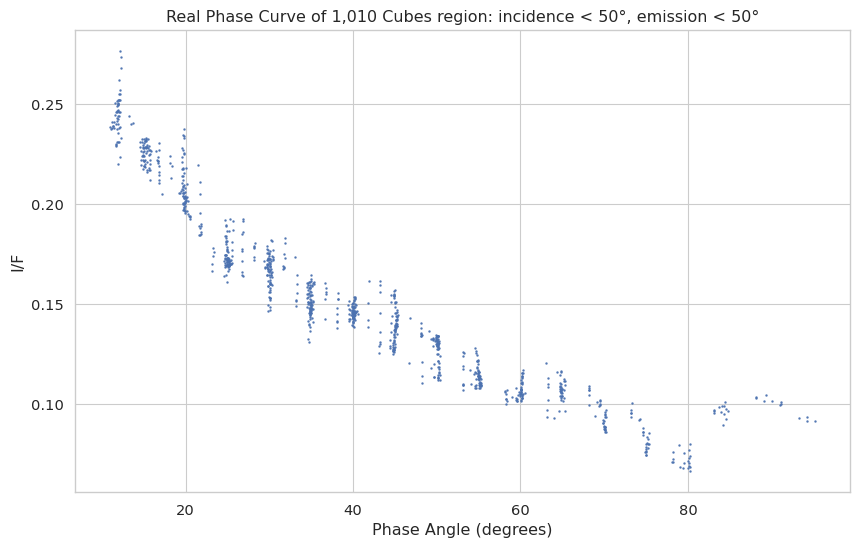

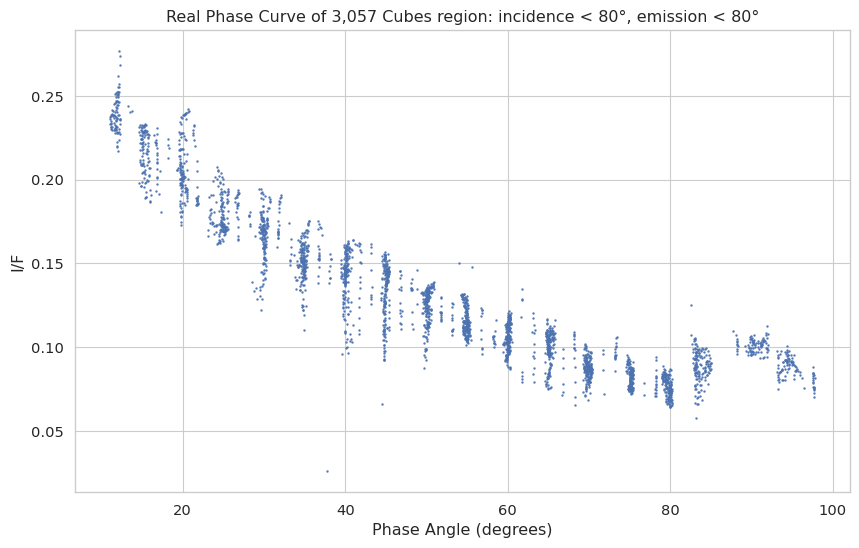

In [11]:



dsk256_lt50_sample = df_binned_dsk256_lt50#.collect().sample(fraction=0.05, seed=42)
plt.scatter(dsk256_lt50_sample["mean_phase"], dsk256_lt50_sample["mean_iof"], alpha=0.8, s=1)
plt.title(f"Real Phase Curve of {len(dsk256_lt50_sample):,} Cubes region: incidence < 50°, emission < 50°")
plt.xlabel("Phase Angle (degrees)")
plt.ylabel("I/F")
plt.grid(True)
plt.show()


dsk256_lt80_sample = df_binned_dsk256_lt80#.collect().sample(fraction=0.05, seed=42)
plt.scatter(dsk256_lt80_sample["mean_phase"], dsk256_lt80_sample["mean_iof"], alpha=0.8, s=1)
plt.title(f"Real Phase Curve of {len(dsk256_lt80_sample):,} Cubes region: incidence < 80°, emission < 80°")
plt.xlabel("Phase Angle (degrees)")
plt.ylabel("I/F")
plt.grid(True)
plt.show()


In [12]:
## Geometry Ingestion and weights 
 

valid_mask_dsk256_lt50 = (
    (df_binned_dsk256_lt50["mean_phase"] <= 98.0) & 
    (df_binned_dsk256_lt50  ["std_iof"] > 0.0)    
)


# Re-apply mask correctly on rows (pandas .filter() was dropping columns)
df_binned_cleaned_dsk256_lt50 = df_binned_dsk256_lt50[valid_mask_dsk256_lt50].copy()    

print(f"Domain mask applied. Final cube count: {len(df_binned_cleaned_dsk256_lt50)}")

required_cols = ["mean_incidence", "mean_emission", "mean_phase"]
missing = [c for c in required_cols if c not in df_binned_cleaned_dsk256_lt50.columns]
if missing:
    raise KeyError(f"Missing required columns after masking: {missing}")

geom_clean_dsk256_lt50 = GeometryBatch(
    incidence=np.deg2rad(df_binned_cleaned_dsk256_lt50["mean_incidence"].to_numpy()),
    emission=np.deg2rad(df_binned_cleaned_dsk256_lt50["mean_emission"].to_numpy()),
    phase=np.deg2rad(df_binned_cleaned_dsk256_lt50["mean_phase"].to_numpy())
)




# --- Principled weighting: standard error + systematic floor in quadrature ---

n_pixels_arr_dsk256_lt50 = df_binned_cleaned_dsk256_lt50["n_pixels"].to_numpy()
std_iof_arr_dsk256_lt50  = df_binned_cleaned_dsk256_lt50["std_iof"].to_numpy()
measured_iof_dsk256_lt50 = df_binned_cleaned_dsk256_lt50["mean_iof"].to_numpy()

stat_error_dsk256_lt50 = np.maximum(std_iof_arr_dsk256_lt50, 1e-9) / np.sqrt(n_pixels_arr_dsk256_lt50)

# Derive the floor from YOUR measured residual decomposition, don't assert it:
# CV_other ≈ 8.3% of global mean I/F is the irreducible per-bin systematic
sys_floor_dsk256_lt50 = 0.083 * measured_iof_dsk256_lt50.mean()   # ≈ 0.012 in I/F, derived not assumed

total_error_dsk256_lt50 = np.sqrt(stat_error_dsk256_lt50**2 + sys_floor_dsk256_lt50**2)
weights_dsk256_lt50 = 1.0 / total_error_dsk256_lt50






#std_iof_arr = df_binned_cleaned_dsk["std_iof"].to_numpy()
#weights_inv_sigma_dsk = 1.0 / np.maximum(std_iof_arr, 1e-9)



# --- DIAGNOSTIC BLOCK ---
print(f"Max Phase Angle: {np.rad2deg(geom_clean_dsk256_lt50.phase).max():.2f} deg")

print(f"Max Incidence Angle: {np.rad2deg(geom_clean_dsk256_lt50.incidence).max():.2f} deg")
print(f"Weight Ratio (Max/Min): {weights_dsk256_lt50.max() / weights_dsk256_lt50.min():.2f}")
print(f"Data points passed to fitter: {len(measured_iof_dsk256_lt50)}")



# Check the number of bins
print(f"Total bins in dataset: {len(measured_iof_dsk256_lt50)}")
# Check the average number of pixels per bin
print(f"Average pixels per bin: {df_binned_cleaned_dsk256_lt50['n_pixels'].mean():.2f}")





Domain mask applied. Final cube count: 1010
Max Phase Angle: 95.15 deg
Max Incidence Angle: 48.96 deg
Weight Ratio (Max/Min): 1.01
Data points passed to fitter: 1010
Total bins in dataset: 1010
Average pixels per bin: 221481.06


In [16]:
## Geometry Ingestion and weights 
 

valid_mask_dsk256_lt80 = (
    (df_binned_dsk256_lt80["mean_phase"] <= 98.0) & 
    (df_binned_dsk256_lt80  ["std_iof"] > 0.0)    
)


# Re-apply mask correctly on rows (pandas .filter() was dropping columns)
df_binned_cleaned_dsk256_lt80 = df_binned_dsk256_lt80[valid_mask_dsk256_lt80].copy()    

print(f"Domain mask applied. Final cube count: {len(df_binned_cleaned_dsk256_lt80)}")

required_cols = ["mean_incidence", "mean_emission", "mean_phase"]
missing = [c for c in required_cols if c not in df_binned_cleaned_dsk256_lt80.columns]
if missing:
    raise KeyError(f"Missing required columns after masking: {missing}")

geom_clean_dsk256_lt80 = GeometryBatch(
    incidence=np.deg2rad(df_binned_cleaned_dsk256_lt80["mean_incidence"].to_numpy()),
    emission=np.deg2rad(df_binned_cleaned_dsk256_lt80["mean_emission"].to_numpy()),
    phase=np.deg2rad(df_binned_cleaned_dsk256_lt80["mean_phase"].to_numpy())
)




# --- Principled weighting: standard error + systematic floor in quadrature ---

n_pixels_arr_dsk256_lt80 = df_binned_cleaned_dsk256_lt80["n_pixels"].to_numpy()
std_iof_arr_dsk256_lt80 = df_binned_cleaned_dsk256_lt80["std_iof"].to_numpy()
measured_iof_dsk256_lt80 = df_binned_cleaned_dsk256_lt80["mean_iof"].to_numpy()

stat_error_dsk256_lt80 = np.maximum(std_iof_arr_dsk256_lt80, 1e-9) / np.sqrt(n_pixels_arr_dsk256_lt80)

# Derive the floor from YOUR measured residual decomposition, don't assert it:
# CV_other ≈ 8.3% of global mean I/F is the irreducible per-bin systematic
sys_floor_dsk256_lt80 = 0.083 * measured_iof_dsk256_lt80.mean()   # ≈ 0.012 in I/F, derived not assumed

total_error_dsk256_lt80 = np.sqrt(stat_error_dsk256_lt80**2 + sys_floor_dsk256_lt80**2)
weights_dsk256_lt80 = 1.0 / total_error_dsk256_lt80     






#std_iof_arr = df_binned_cleaned_dsk["std_iof"].to_numpy()
#weights_inv_sigma_dsk = 1.0 / np.maximum(std_iof_arr, 1e-9)



# --- DIAGNOSTIC BLOCK ---
print(f"Max Phase Angle: {np.rad2deg(geom_clean_dsk256_lt80.phase).max():.2f} deg")

print(f"Max Incidence Angle: {np.rad2deg(geom_clean_dsk256_lt80.incidence).max():.2f} deg")
print(f"Weight Ratio (Max/Min): {weights_dsk256_lt80.max() / weights_dsk256_lt80.min():.2f}")
print(f"Data points passed to fitter: {len(measured_iof_dsk256_lt80)}")
# ------------------------


# Check the number of bins
print(f"Total bins in dataset: {len(measured_iof_dsk256_lt80)}")
# Check the average number of pixels per bin
print(f"Average pixels per bin: {df_binned_cleaned_dsk256_lt80['n_pixels'].mean():.2f}")





Domain mask applied. Final cube count: 3057
Max Phase Angle: 97.78 deg
Max Incidence Angle: 79.50 deg
Weight Ratio (Max/Min): 1.59
Data points passed to fitter: 3057
Total bins in dataset: 3057
Average pixels per bin: 148584.68


# Case 1 fitting: 
## Fixed:  B0 = 1.03, h = 0.04
## Varying: w,g,theta-bar

In [25]:
# Model initiation

model_case1_dsk256_lt50 = HapkeModel(enable_shoe=True, enable_roughness=True, fixed_parameters={'B0': 1.03, 'h': 0.04}) #, 'w': 0.511, 'g': -0.294})


fitter = LeastSquaresFitter()


results_summary_dsk256_lt50 = {}



print(f"Optimizing: {model_case1_dsk256_lt50.parameter_names()}")

# Verify the hijack worked
#print(f"\nModel initialized. Active parameters mapped to Jacobian: {model_case1.parameter_names()}")
#print(f"Fixed parameters running in background: B0={model_case1.parameters['B0']}, h={model_case1.parameters['h']}, theta_bar={model_case1.parameters['theta_bar']} degrees") # theta_bar fixed
#print(f"Fixed parameters running in background: B0={model_case1.parameters['B0']}, h={model_case1.parameters['h']}")
#print(f"Fixed parameters running in background: theta_bar={model.parameters['theta_bar']} degrees") # theta_bar fixed





# Multi-Start Generator (5D Space)

n_starts = 100
np.random.seed(42)
initial_guesses_case1_dsk256_lt50 = [
    {
        "w": np.random.uniform(0.3, 0.6),
        "g": np.random.uniform(-0.4, -0.2),
        "theta_bar":np.random.uniform(1.0,30.0),#(1.0, 30.0), # in degrees, will be converted to radians inside the model
       #'B0': np.random.uniform(0.3, 2.0),  # SHOE Amplitude
      # 'h': np.random.uniform(0.01, 0.15)   #
    }

    for _ in range(n_starts)
]

best_cost_case1_dsk256_lt50 = np.inf
best_result_case1_dsk256_lt50 = None

for guess in initial_guesses_case1_dsk256_lt50:
    model_case1_dsk256_lt50.parameters.update(guess)
    
    result = fitter.fit(
        model=model_case1_dsk256_lt50,
        geometry=geom_clean_dsk256_lt50,
        observed_reflectance=measured_iof_dsk256_lt50,
        weights=weights_dsk256_lt50
    )
    
    if result.metadata["success"] and result.objective_value < best_cost_case1_dsk256_lt50:
        best_cost_case1_dsk256_lt50 = result.objective_value
        best_result_case1_dsk256_lt50 = result

if best_result_case1_dsk256_lt50 is None:
    raise RuntimeError("Optimization collapsed. No multi-start vectors converged.")

#  

print("Parameter fitting complete.")
print(f"Cost: {best_result_case1_dsk256_lt50.objective_value:.4f}")

for param_name, value in best_result_case1_dsk256_lt50.fitted_parameters.items():
    print(f"{param_name}: {value:.4f}")

print("Parameter uncertainties (1-Sigma)")
if best_result_case1_dsk256_lt50.metadata.get("parameter_errors"):
    for param_name, error in best_result_case1_dsk256_lt50.metadata["parameter_errors"].items():
        print(f"{param_name}: +/- {error:.4f}")
else:
    print("Jacobian failed to invert (Flat gradient detected).")


results_summary_dsk256_lt50["Case 1 (3-Param)"] = best_result_case1_dsk256_lt50.fitted_parameters.copy()


    

Optimizing: ['w', 'g', 'theta_bar']
Parameter fitting complete.
Cost: 697.1303
w: 0.4656
g: -0.3325
theta_bar: 8.3844
Parameter uncertainties (1-Sigma)
w: +/- 0.0023
g: +/- 0.0033
theta_bar: +/- 1.1575


In [17]:
# Model initiation

model_case1_dsk256_lt80 = HapkeModel(enable_shoe=True, enable_roughness=True, fixed_parameters={'B0': 1.03, 'h': 0.04}) #, 'w': 0.511, 'g': -0.294})


fitter = LeastSquaresFitter()


results_summary_dsk256_lt80 = {}



print(f"Optimizing: {model_case1_dsk256_lt80.parameter_names()}")

# Verify the hijack worked
#print(f"\nModel initialized. Active parameters mapped to Jacobian: {model_case1.parameter_names()}")
#print(f"Fixed parameters running in background: B0={model_case1.parameters['B0']}, h={model_case1.parameters['h']}, theta_bar={model_case1.parameters['theta_bar']} degrees") # theta_bar fixed
#print(f"Fixed parameters running in background: B0={model_case1.parameters['B0']}, h={model_case1.parameters['h']}")
#print(f"Fixed parameters running in background: theta_bar={model.parameters['theta_bar']} degrees") # theta_bar fixed





# Multi-Start Generator (5D Space)

n_starts = 100
np.random.seed(42)
initial_guesses_case1_dsk256_lt80 = [
    {
        "w": np.random.uniform(0.3, 0.6),
        "g": np.random.uniform(-0.4, -0.2),
        "theta_bar":np.random.uniform(1.0,30.0),#(1.0, 30.0), # in degrees, will be converted to radians inside the model
       #'B0': np.random.uniform(0.3, 2.0),  # SHOE Amplitude
      # 'h': np.random.uniform(0.01, 0.15)   #
    }

    for _ in range(n_starts)
]

best_cost_case1_dsk256_lt80 = np.inf
best_result_case1_dsk256_lt80 = None

for guess in initial_guesses_case1_dsk256_lt80:
    model_case1_dsk256_lt80.parameters.update(guess)
    
    result = fitter.fit(
        model=model_case1_dsk256_lt80,
        geometry=geom_clean_dsk256_lt80,
        observed_reflectance=measured_iof_dsk256_lt80,
        weights=weights_dsk256_lt80
    )
    
    if result.metadata["success"] and result.objective_value < best_cost_case1_dsk256_lt80:
        best_cost_case1_dsk256_lt80 = result.objective_value
        best_result_case1_dsk256_lt80 = result

if best_result_case1_dsk256_lt80 is None:
    raise RuntimeError("Optimization collapsed. No multi-start vectors converged.")

#  

print("Parameter fitting complete.")
print(f"Cost: {best_result_case1_dsk256_lt80.objective_value:.4f}")

for param_name, value in best_result_case1_dsk256_lt80.fitted_parameters.items():
    print(f"{param_name}: {value:.4f}")

print("Parameter uncertainties (1-Sigma)")
if best_result_case1_dsk256_lt80.metadata.get("parameter_errors"):
    for param_name, error in best_result_case1_dsk256_lt80.metadata["parameter_errors"].items():
        print(f"{param_name}: +/- {error:.4f}")
else:
    print("Jacobian failed to invert (Flat gradient detected).")


results_summary_dsk256_lt80["Case 1 (3-Param)"] = best_result_case1_dsk256_lt80.fitted_parameters.copy()

    

Optimizing: ['w', 'g', 'theta_bar']
Parameter fitting complete.
Cost: 11946.6604
w: 0.4444
g: -0.3384
theta_bar: 0.6061
Parameter uncertainties (1-Sigma)
w: +/- 0.0406
g: +/- 0.0067
theta_bar: +/- 209.8656


## Case 2 fitting: 
## Fixed:  B0 = 1.03
## Varying: w,g,h,theta-bar

In [33]:
# Model initiation

model_case2_dsk256_lt50 = HapkeModel(enable_shoe=True, enable_roughness=True, fixed_parameters={'B0': 1.03})





fitter = LeastSquaresFitter()

results_summary_dsk256_lt50 = {}


print(f"Optimizing: {model_case2_dsk256_lt50.parameter_names()}")







# Multi-Start Generator (5D Space)

n_starts = 100
np.random.seed(42)
initial_guesses_case2_dsk256_lt50 = [
    {
        "w": np.random.uniform(0.3, 0.6),
        "g": np.random.uniform(-0.4, -0.2),
        "theta_bar":np.random.uniform(1.0,30.0),#(1.0, 30.0), # in degrees, will be converted to radians inside the model
        'h': np.random.uniform(0.01, 0.15)   #
    }

    for _ in range(n_starts)
]

best_cost_case2_dsk256_lt50 = np.inf
best_result_case2_dsk256_lt50 = None

for guess in initial_guesses_case2_dsk256_lt50:
    model_case2_dsk256_lt50.parameters.update(guess)
    
    result = fitter.fit(
        model=model_case2_dsk256_lt50,
        geometry=geom_clean_dsk256_lt50,
        observed_reflectance=measured_iof_dsk256_lt50,
        weights=weights_dsk256_lt50
    )
    
    if result.metadata["success"] and result.objective_value < best_cost_case2_dsk256_lt50:
        best_cost_case2_dsk256_lt50 = result.objective_value
        best_result_case2_dsk256_lt50 = result

if best_result_case2_dsk256_lt50 is None:
    raise RuntimeError("Optimization collapsed. No multi-start vectors converged.")

#  

print("Parameter fitting complete.")
print(f"Cost: {best_result_case2_dsk256_lt50.objective_value:.4f}")

for param_name, value in best_result_case2_dsk256_lt50.fitted_parameters.items():
    print(f"{param_name}: {value:.4f}")

print("Parameter uncertainties (1-Sigma)")
if best_result_case2_dsk256_lt50.metadata.get("parameter_errors"):
    for param_name, error in best_result_case2_dsk256_lt50.metadata["parameter_errors"].items():
        print(f"{param_name}: +/- {error:.4f}")
else:
    print("Jacobian failed to invert (Flat gradient detected).")


results_summary_dsk256_lt50["Case 2 (4-Param)"] = best_result_case2_dsk256_lt50.fitted_parameters.copy()



Optimizing: ['w', 'g', 'theta_bar', 'h']
Parameter fitting complete.
Cost: 681.6376
w: 0.4527
g: -0.3083
theta_bar: 7.8052
h: 0.0805
Parameter uncertainties (1-Sigma)
w: +/- 0.0663
g: +/- 0.0840
theta_bar: +/- 1.6193
h: +/- 0.2143


In [ ]:
# Model initiation

model_case2_dsk256_lt80 = HapkeModel(enable_shoe=True, enable_roughness=True, fixed_parameters={'B0': 1.03})





fitter = LeastSquaresFitter()


print(f"Optimizing: {model_case2_dsk256_lt80.parameter_names()}")







# Multi-Start Generator (5D Space)

n_starts = 100
np.random.seed(42)
initial_guesses_case2_dsk256_lt80 = [
    {
        "w": np.random.uniform(0.3, 0.6),
        "g": np.random.uniform(-0.4, -0.2),
        "theta_bar":np.random.uniform(1.0,30.0),#(1.0, 30.0), # in degrees, will be converted to radians inside the model
        'h': np.random.uniform(0.01, 0.15)   #
    }

    for _ in range(n_starts)
]

best_cost_case2_dsk256_lt80 = np.inf
best_result_case2_dsk256_lt80 = None

for guess in initial_guesses_case2_dsk256_lt80:
    model_case2_dsk256_lt80.parameters.update(guess)
    
    result = fitter.fit(
        model=model_case2_dsk256_lt80,
        geometry=geom_clean_dsk256_lt80,
        observed_reflectance=measured_iof_dsk256_lt80,
        weights=weights_dsk256_lt80
    )
    
    if result.metadata["success"] and result.objective_value < best_cost_case2_dsk256_lt80:
        best_cost_case2_dsk256_lt80 = result.objective_value
        best_result_case2_dsk256_lt80 = result

if best_result_case2_dsk256_lt80 is None:
    raise RuntimeError("Optimization collapsed. No multi-start vectors converged.")

#  

print("Parameter fitting complete.")
print(f"Cost: {best_result_case2_dsk256_lt80.objective_value:.4f}")

for param_name, value in best_result_case2_dsk256_lt80.fitted_parameters.items():
    print(f"{param_name}: {value:.4f}")

print("Parameter uncertainties (1-Sigma)")
if best_result_case2_dsk256_lt80.metadata.get("parameter_errors"):
    for param_name, error in best_result_case2_dsk256_lt80.metadata["parameter_errors"].items():
        print(f"{param_name}: +/- {error:.4f}")
else:
    print("Jacobian failed to invert (Flat gradient detected).")


results_summary_dsk256_lt80["Case 2 (4-Param)"] = best_result_case2_dsk256_lt80.fitted_parameters.copy()



Optimizing: ['w', 'g', 'theta_bar', 'h']
Parameter fitting complete.
Cost: 11932.2479
w: 0.4366
g: -0.3255
theta_bar: 0.5973
h: 0.0610
Parameter uncertainties (1-Sigma)
w: +/- 0.0493
g: +/- 0.0278
theta_bar: +/- 238.2046
h: +/- 0.0532


## Case 3 fitting: 
## Fixed: None
## Varying: w,g,h,B0,theta-bar

In [21]:
# Model initiation

model_case3_dsk256_lt50 = HapkeModel(enable_shoe=True, enable_roughness=True, fixed_parameters={}) # No fixed parameters, all 5 are free to vary.

fitter = LeastSquaresFitter()

results_summary_dsk256_lt50 = {}


print(f"Optimizing: {model_case3_dsk256_lt50.parameter_names()}")







# Multi-Start Generator (5D Space)

n_starts = 100
np.random.seed(42)
initial_guesses_case3_dsk256_lt50 = [
    {
        "w": np.random.uniform(0.3, 0.6),
        "g": np.random.uniform(-0.4, -0.2),
        "theta_bar":np.random.uniform(1.0,30.0),# in degrees, will be converted to radians inside the model
       'B0': np.random.uniform(0.3, 2.0),  # SHOE Amplitude
      'h': np.random.uniform(0.01, 0.15)   #
    }

    for _ in range(n_starts)
]

best_cost_case3_dsk256_lt50 = np.inf
best_result_case3_dsk256_lt50 = None

for guess in initial_guesses_case3_dsk256_lt50:
    model_case3_dsk256_lt50.parameters.update(guess)
    
    result = fitter.fit(
        model=model_case3_dsk256_lt50,
        geometry=geom_clean_dsk256_lt50,
        observed_reflectance=measured_iof_dsk256_lt50,
        weights=weights_dsk256_lt50
    )
    
    if result.metadata["success"] and result.objective_value < best_cost_case3_dsk256_lt50:
        best_cost_case3_dsk256_lt50 = result.objective_value
        best_result_case3_dsk256_lt50 = result

if best_result_case3_dsk256_lt50 is None:
    raise RuntimeError("Optimization collapsed. No multi-start vectors converged.")

#  

print("Parameter fitting complete.")
print(f"Cost: {best_result_case3_dsk256_lt50.objective_value:.4f}")

for param_name, value in best_result_case3_dsk256_lt50.fitted_parameters.items():
    print(f"{param_name}: {value:.4f}")

print("Parameter uncertainties (1-Sigma)")
if best_result_case3_dsk256_lt50.metadata.get("parameter_errors"):
    for param_name, error in best_result_case3_dsk256_lt50.metadata["parameter_errors"].items():
        print(f"{param_name}: +/- {error:.4f}")
else:
    print("Jacobian failed to invert (Flat gradient detected).")

results_summary_dsk256_lt50["Case 3 (5-Param)"] = best_result_case3_dsk256_lt50.fitted_parameters.copy()

    

Optimizing: ['w', 'g', 'theta_bar', 'B0', 'h']
Parameter fitting complete.
Cost: 623.3864
w: 0.4367
g: -0.2576
theta_bar: 5.6722
B0: 2.0000
h: 0.0725
Parameter uncertainties (1-Sigma)
w: +/- 0.0534
g: +/- 0.0685
theta_bar: +/- 3.8277
B0: +/- 0.2426
h: +/- 0.0970


In [22]:
# Model initiation

model_case3_dsk256_lt80 = HapkeModel(enable_shoe=True, enable_roughness=True, fixed_parameters={}) # No fixed parameters, all 5 are free to vary.

fitter = LeastSquaresFitter()

results_summary_dsk256_lt80 = {}


print(f"Optimizing: {model_case3_dsk256_lt80.parameter_names()}")







# Multi-Start Generator (5D Space)

n_starts = 100
np.random.seed(42)
initial_guesses_case3_dsk256_lt80 = [
    {
        "w": np.random.uniform(0.3, 0.6),
        "g": np.random.uniform(-0.4, -0.2),
        "theta_bar":np.random.uniform(1.0,30.0),# in degrees, will be converted to radians inside the model
       'B0': np.random.uniform(0.3, 2.0),  # SHOE Amplitude
      'h': np.random.uniform(0.01, 0.15)   #
    }

    for _ in range(n_starts)
]

best_cost_case3_dsk256_lt80 = np.inf
best_result_case3_dsk256_lt80 = None

for guess in initial_guesses_case3_dsk256_lt80:
    model_case3_dsk256_lt80.parameters.update(guess)
    
    result = fitter.fit(
        model=model_case3_dsk256_lt80,
        geometry=geom_clean_dsk256_lt80,
        observed_reflectance=measured_iof_dsk256_lt80,
        weights=weights_dsk256_lt80
    )
    
    if result.metadata["success"] and result.objective_value < best_cost_case3_dsk256_lt80:
        best_cost_case3_dsk256_lt80 = result.objective_value
        best_result_case3_dsk256_lt80 = result

if best_result_case3_dsk256_lt80 is None:
    raise RuntimeError("Optimization collapsed. No multi-start vectors converged.")

#  

print("Parameter fitting complete.")
print(f"Cost: {best_result_case3_dsk256_lt80.objective_value:.4f}")

for param_name, value in best_result_case3_dsk256_lt80.fitted_parameters.items():
    print(f"{param_name}: {value:.4f}")

print("Parameter uncertainties (1-Sigma)")
if best_result_case3_dsk256_lt80.metadata.get("parameter_errors"):
    for param_name, error in best_result_case3_dsk256_lt80.metadata["parameter_errors"].items():
        print(f"{param_name}: +/- {error:.4f}")
else:
    print("Jacobian failed to invert (Flat gradient detected).")

results_summary_dsk256_lt80["Case 3 (5-Param)"] = best_result_case3_dsk256_lt80.fitted_parameters.copy()

    

Optimizing: ['w', 'g', 'theta_bar', 'B0', 'h']
Parameter fitting complete.
Cost: 11835.6378
w: 0.4267
g: -0.2977
theta_bar: 0.5841
B0: 2.0000
h: 0.0456
Parameter uncertainties (1-Sigma)
w: +/- 0.0558
g: +/- 0.0339
theta_bar: +/- 312.6939
B0: +/- 1.0795
h: +/- 0.0653


In [36]:


best_result_dsk256_lt50 = results_summary_dsk256_lt50.get("Case 1 (3-Param)", best_result_case1_dsk256_lt50)
model_eval_dsk256_lt50 = HapkeModel(enable_shoe=True, enable_roughness=True, fixed_parameters={'B0': 1.03, 'h': 0.04}) # Match the exact configuration of the best result for a clean evaluation
model_eval_dsk256_lt50.parameters.update(best_result_dsk256_lt50.fitted_parameters)

# 2. Generate Predictions
predicted_iof_dsk256_lt50 = model_eval_dsk256_lt50._reflectance_numpy(geom_clean_dsk256_lt50)

# 3. Setup Arrays for Math
obs_dsk256_lt50  = measured_iof_dsk256_lt50
pred_dsk256_lt50 = predicted_iof_dsk256_lt50
resid_dsk256_lt50 = obs_dsk256_lt50 - pred_dsk256_lt50
n_bins_dsk256_lt50 = len(obs_dsk256_lt50)
n_params_dsk256_lt50 = len(best_result_case1_dsk256_lt50.fitted_parameters)
dof_dsk256_lt50 = n_bins_dsk256_lt50 - n_params_dsk256_lt50

# ============ STATISTICAL MATH ============

# 1. CV-RMSE (Schröder Eq. 14 — THE Li et al.-comparable metric)
cv_rmse_dsk256_lt50 = np.sqrt(np.mean(resid_dsk256_lt50**2)) / obs_dsk256_lt50.mean() * 100

# 2. Fractional RMS (per-bin normalized)
frac_rms_dsk256_lt50 = np.sqrt(np.mean((resid_dsk256_lt50 / obs_dsk256_lt50)**2)) * 100

# 3. Reduced chi-square (uses the weights from the proportional floor)
chi2_dsk256_lt50 = np.sum((resid_dsk256_lt50 * weights_dsk256_lt50)**2)
red_chi2_dsk256_lt50 = chi2_dsk256_lt50 / dof_dsk256_lt50

# 4. Mean residual (global bias check)
mean_resid_dsk256_lt50 = resid_dsk256_lt50.mean()

# 5. Residual-vs-incidence slope
inc_deg_dsk256_lt50 = np.rad2deg(geom_clean_dsk256_lt50.incidence)
slope_dsk256_lt50, intercept_dsk256_lt50 = np.polyfit(inc_deg_dsk256_lt50, obs_dsk256_lt50/pred_dsk256_lt50, 1)

# 6. Orthogonal decomposition
inc_bins_dsk256_lt50 = (inc_deg_dsk256_lt50 // 10).astype(int)
r_trend_dsk256_lt50 = np.zeros_like(resid_dsk256_lt50)
for b in np.unique(inc_bins_dsk256_lt50):
    m = inc_bins_dsk256_lt50 == b
    r_trend_dsk256_lt50[m] = resid_dsk256_lt50[m].mean()
r_other_dsk256_lt50 = resid_dsk256_lt50 - r_trend_dsk256_lt50

cv_trend_dsk256_lt50 = np.sqrt(np.mean(r_trend_dsk256_lt50**2)) / obs_dsk256_lt50.mean() * 100
cv_other_dsk256_lt50 = np.sqrt(np.mean(r_other_dsk256_lt50**2)) / obs_dsk256_lt50.mean() * 100

# ============ PRINT SUMMARY ============
print(f"{'CV-RMSE (Schröder Eq.14, vs Li et al. 5%)':45s}: {cv_rmse_dsk256_lt50:6.3f}%")
print(f"{'Fractional RMS (per-bin normalized)':45s}: {frac_rms_dsk256_lt50:6.3f}%")
print(f"{f'Reduced chi-square (dof={dof_dsk256_lt50})':45s}: {red_chi2_dsk256_lt50:6.3f}")
print(f"{'Mean residual (bias)':45s}: {mean_resid_dsk256_lt50:+.5f}")
print(f"{'Ratio-vs-incidence slope':45s}: {slope_dsk256_lt50:+.5f} /deg")
print(f"{'CV_trend (incidence systematic)':45s}: {cv_trend_dsk256_lt50:6.3f}%")
print(f"{'CV_other (within-bin / albedo)':45s}: {cv_other_dsk256_lt50:6.3f}%")
print(f"{'Quadrature check sqrt(trend²+other²)':45s}: {np.sqrt(cv_trend_dsk256_lt50**2+cv_other_dsk256_lt50**2):6.3f}%")
print("==================================================\n")


AttributeError: 'dict' object has no attribute 'fitted_parameters'

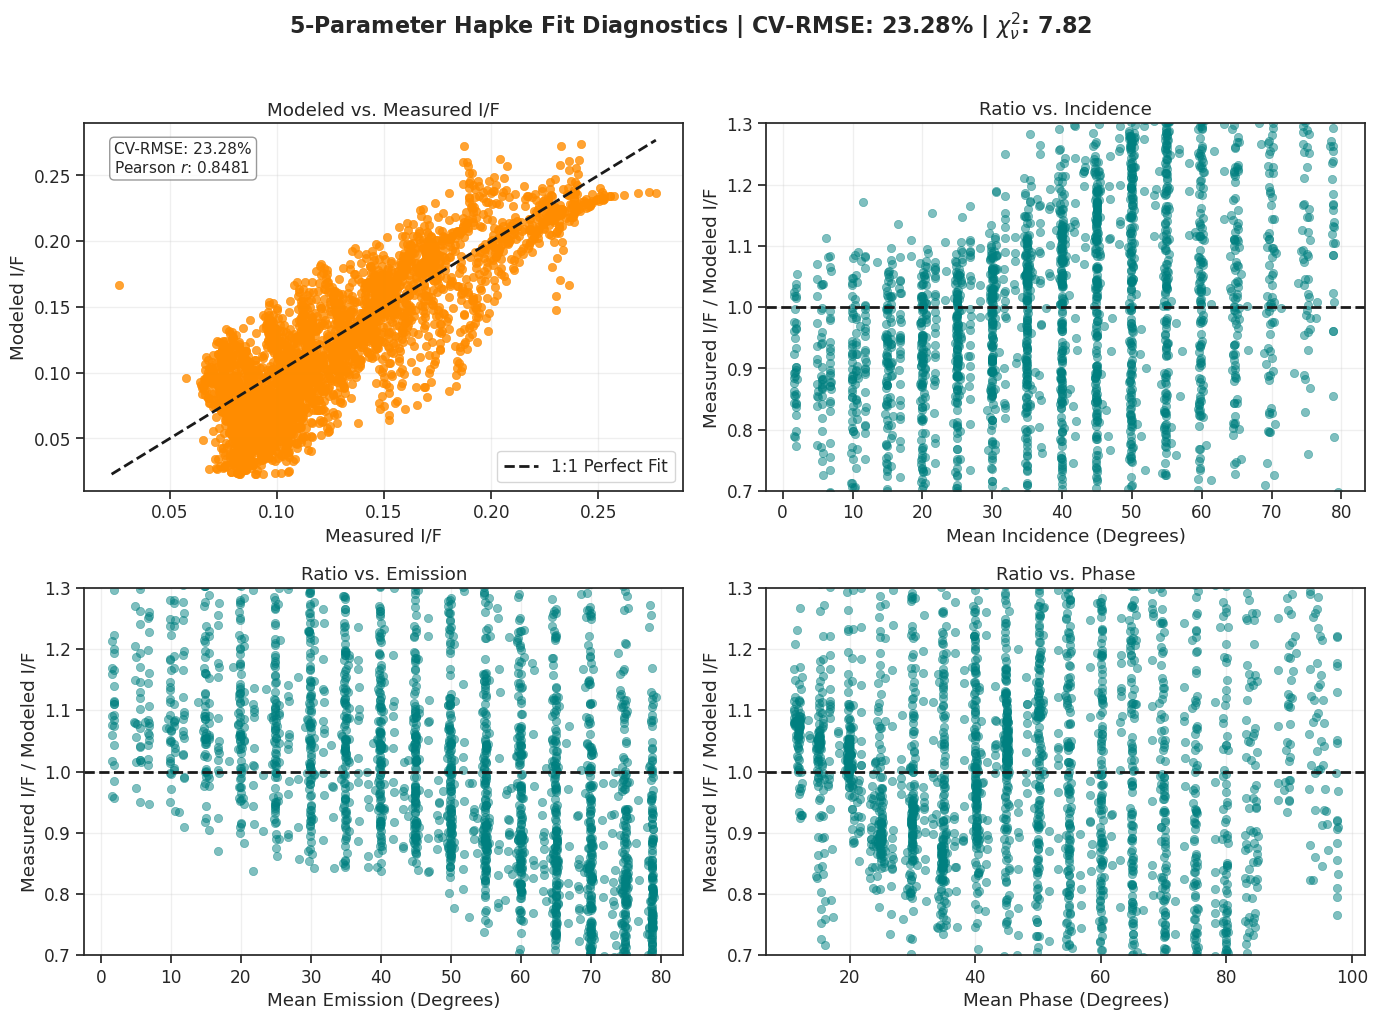

In [46]:
# ============ DIAGNOSTIC PLOTTING ============

# 1. Update the Pandas dataframe with predictions and ratio directly
df_binned_cleaned_dsk["modeled_iof"] = predicted_iof
df_binned_cleaned_dsk["ratio"] = obs / pred

# 2. Since it is ALREADY a Pandas dataframe, we don't need .to_pandas()
df_plot = df_binned_cleaned_dsk.copy()



# Calculate Correlation (Pearson r) between measured and modeled
corr_matrix = np.corrcoef(df_plot['mean_iof'], df_plot['modeled_iof'])
pearson_r = corr_matrix[0, 1]

# Create 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'5-Parameter Hapke Fit Diagnostics | CV-RMSE: {cv_rmse:.2f}% | $\chi^2_\\nu$: {red_chi2:.2f}', 
             fontsize=16, fontweight='bold', y=1.02)

# ---------------------------------------------------------
# Panel [0, 0]: Modeled vs Measured I/F (Absolute Check)
# ---------------------------------------------------------
sns.scatterplot(x=df_plot['mean_iof'], y=df_plot['modeled_iof'], ax=axes[0, 0], alpha=0.8, color='darkorange', edgecolor=None)
axes[0, 0].set_title('Modeled vs. Measured I/F')
axes[0, 0].set_xlabel('Measured I/F')
axes[0, 0].set_ylabel('Modeled I/F')

# Plot the 1:1 Identity Line
min_val = min(df_plot['mean_iof'].min(), df_plot['modeled_iof'].min())
max_val = max(df_plot['mean_iof'].max(), df_plot['modeled_iof'].max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='1:1 Perfect Fit')

# Add Metrics Text Box
textstr = f'CV-RMSE: {cv_rmse:.2f}%\nPearson $r$: {pearson_r:.4f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
axes[0, 0].text(0.05, 0.95, textstr, transform=axes[0, 0].transAxes, fontsize=11,
                verticalalignment='top', bbox=props)
axes[0, 0].legend(loc='lower right')

# ---------------------------------------------------------
# Panel [0, 1]: Ratio vs Incidence
# ---------------------------------------------------------
sns.scatterplot(x=df_plot['mean_incidence'], y=df_plot['ratio'], ax=axes[0, 1], alpha=0.5, color='teal', edgecolor=None)
axes[0, 1].set_title('Ratio vs. Incidence')
axes[0, 1].set_xlabel('Mean Incidence (Degrees)')

# ---------------------------------------------------------
# Panel [1, 0]: Ratio vs Emission
# ---------------------------------------------------------
sns.scatterplot(x=df_plot['mean_emission'], y=df_plot['ratio'], ax=axes[1, 0], alpha=0.5, color='teal', edgecolor=None)
axes[1, 0].set_title('Ratio vs. Emission')
axes[1, 0].set_xlabel('Mean Emission (Degrees)')

# ---------------------------------------------------------
# Panel [1, 1]: Ratio vs Phase
# ---------------------------------------------------------
sns.scatterplot(x=df_plot['mean_phase'], y=df_plot['ratio'], ax=axes[1, 1], alpha=0.5, color='teal', edgecolor=None)
axes[1, 1].set_title('Ratio vs. Phase')
axes[1, 1].set_xlabel('Mean Phase (Degrees)')

# ---------------------------------------------------------
# Standardize Formatting
# ---------------------------------------------------------
# Apply ratio-specific formatting only to the 3 residual ratio plots
for ax in [axes[0, 1], axes[1, 0], axes[1, 1]]:
    ax.axhline(1.0, color='k', ls='--', lw=2)
    ax.set_ylim(0.7, 1.3)
    ax.set_ylabel('Measured I/F / Modeled I/F')

# Apply grid to all 4 panels
for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Plotting landscape from 100 successful multi-start convergences.


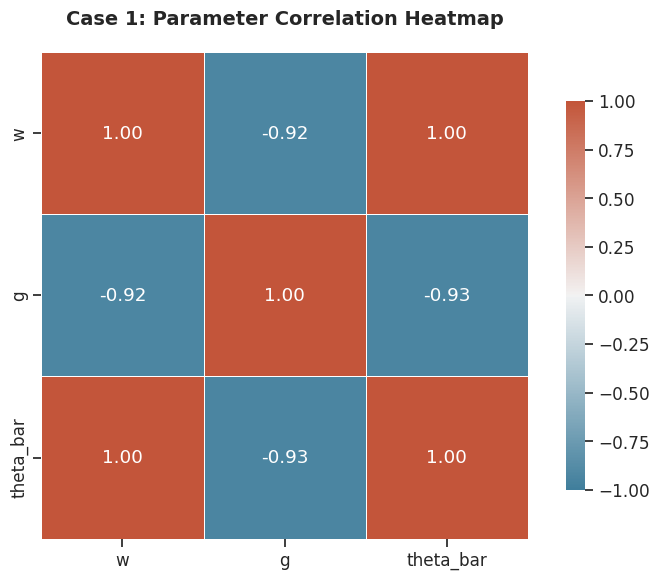

In [47]:
# ==========================================
# 1. EXTRACT MULTI-START DATA (Case 3 Example)
# ==========================================
# We will extract the fitted parameters from every successful multi-start
# to see how the optimizer explored the space.

successful_params_case1 = []

# Assuming 'guesses_case3' and 'model_case3' and the 'fitter' loop are available.
# (If you didn't save all results previously, we just quickly re-run the loop to capture them)
for guess in initial_guesses_case1:
    model_case1.parameters.update(guess)
    res = fitter.fit(model_case1 , geom_clean_dsk, measured_iof_dsk, weights)
    
    if res.metadata["success"]:
        # Save the cost and the fitted parameters
        row = {'Cost': res.objective_value}
        row.update(res.fitted_parameters)
        successful_params_case1.append(row)
        # keep legacy variable name used later
        successful_params_case1 = successful_params_case1

df_params = pd.DataFrame(successful_params_case1)

# Filter out completely failed runaway fits (keep costs reasonably close to the minimum)
min_cost = df_params['Cost'].min()
df_params_clean = df_params[df_params['Cost'] < min_cost * 1.5].drop(columns=['Cost'])

print(f"Plotting landscape from {len(df_params_clean)} successful multi-start convergences.")

# ==========================================

# 2. PLOT: CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(8, 6))
plt.title("Case 1: Parameter Correlation Heatmap", fontsize=14, fontweight='bold', pad=20)

# Calculate the correlation matrix
corr_matrix = df_params_clean.corr()

# Create a custom diverging colormap (Blue for negative, Red for positive)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.tight_layout()
plt.show()



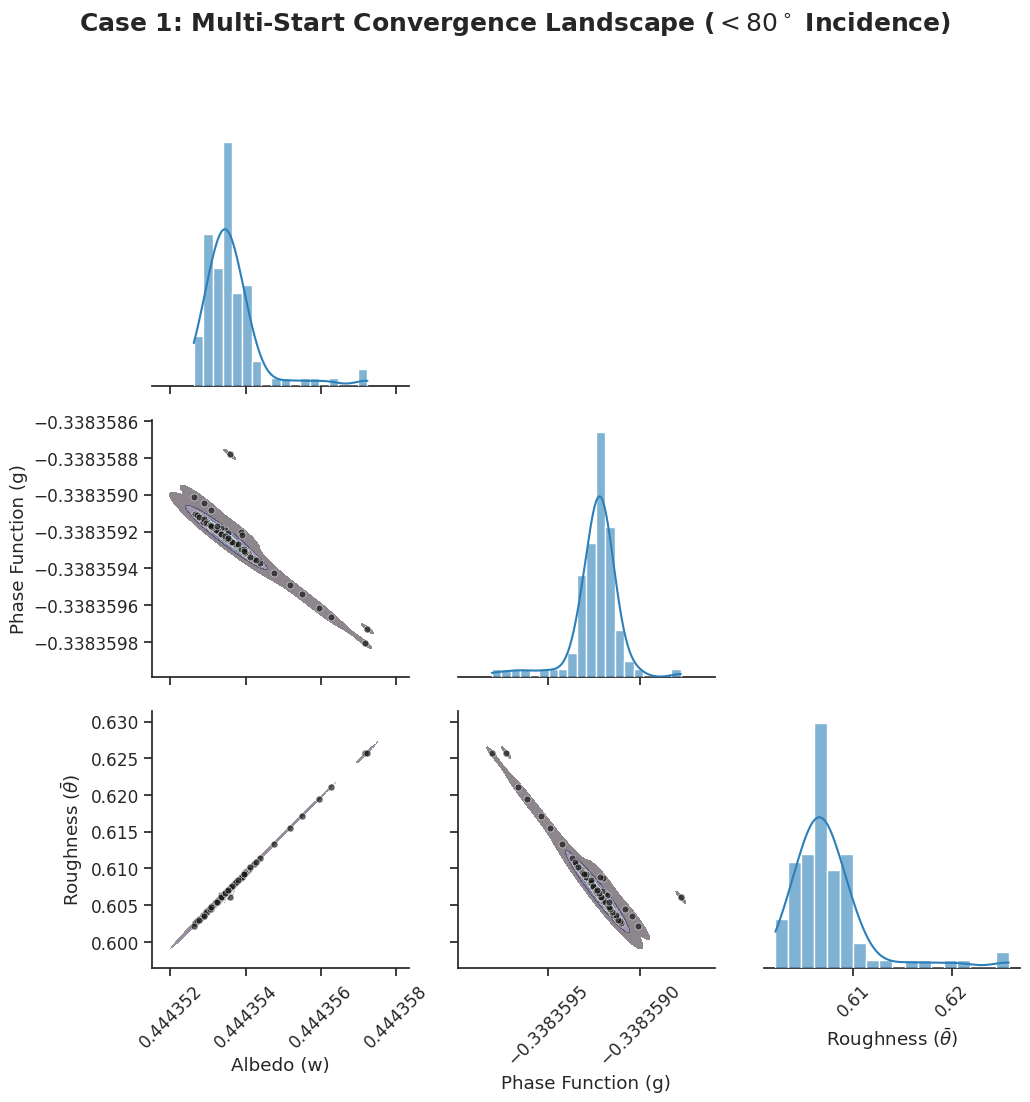

In [49]:
# 1. Set a clean, academic style and boost font sizes
sns.set_theme(style="ticks", font_scale=1.1)

# 2. Create the PairGrid (using 'height' to make the panels larger)
g = sns.PairGrid(df_params_clean, diag_sharey=False, corner=True, height=3.5)

# 3. Map the lower triangle: Smooth KDE contours + precise scatter points
g.map_lower(sns.kdeplot, fill=True, cmap="mako", alpha=0.5, levels=6)
g.map_lower(sns.scatterplot, color=".1", s=25, alpha=0.7, edgecolor="white", linewidth=0.5)

# 4. Map the diagonal: Clean histograms showing the tight convergence
g.map_diag(sns.histplot, color="#2c7fb8", kde=True, linewidth=1, alpha=0.6)

# 5. THE CRITICAL FIX: Disable the confusing 1e-6 scientific offset
for ax in g.axes.flatten():
    if ax is not None:
        # Force plain text formatting for the tick labels
        ax.ticklabel_format(useOffset=False, style='plain', axis='both')
        # Rotate x-axis labels slightly so they don't overlap
        ax.tick_params(axis='x', rotation=45)

# 6. Set proper parameter labels (using LaTeX for the axis titles)
g.axes[1, 0].set_ylabel('Phase Function (g)')
g.axes[2, 0].set_ylabel('Roughness ($\\bar{\\theta}$)')
g.axes[2, 0].set_xlabel('Albedo (w)')
g.axes[2, 1].set_xlabel('Phase Function (g)')
g.axes[2, 2].set_xlabel('Roughness ($\\bar{\\theta}$)')

# 7. Add the master title
g.figure.suptitle("Case 1: Multi-Start Convergence Landscape ($<80^\circ$ Incidence)", 
                  fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

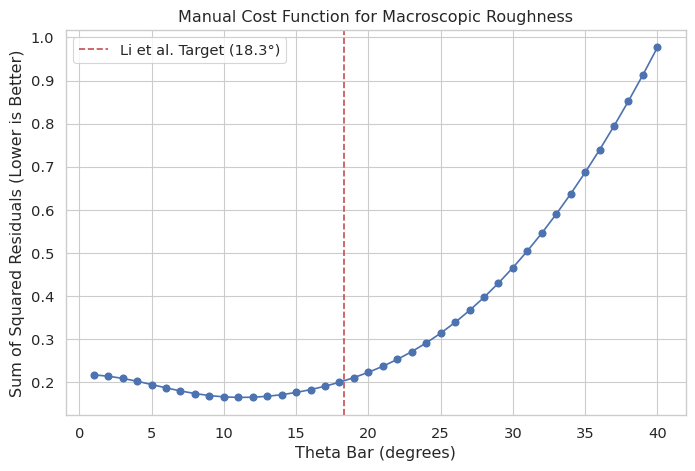

Mathematical Minimum Cost is at Theta = 11.0 degrees


In [14]:

model_testing = HapkeModel(enable_shoe=True, enable_roughness=True)
model_testing.parameters["w"] = 0.511
model_testing.parameters["g"] = -0.294
model_testing.parameters["B0"] = 1.03
model_testing.parameters["h"] = 0.04

# 2. Test Roughness from 1 to 40 degrees
test_thetas = np.linspace(1.0, 40.0, 40)
costs = []

for theta in test_thetas:

    model_testing.parameters["theta_bar"] = theta
    
    # Calculate expected I/F using your existing _reflectance_numpy
    predicted = model_testing._reflectance_numpy(geom_clean_dsk) 
    
    # Calculate sum of squared residuals (cost)
    residuals = predicted - measured_iof_dsk
    cost = 0.5 * np.sum(residuals**2)
    costs.append(cost)

# 3. Plot the Cost Function
plt.figure(figsize=(8, 5))
plt.plot(test_thetas, costs, marker='o')
plt.title("Manual Cost Function for Macroscopic Roughness")
plt.xlabel("Theta Bar (degrees)")
plt.ylabel("Sum of Squared Residuals (Lower is Better)")
plt.axvline(18.3, color='r', linestyle='--', label="Li et al. Target (18.3°)")
plt.legend()
plt.grid(True)
plt.show()

# Print the theta that gives the lowest cost
best_theta = test_thetas[np.argmin(costs)]
print(f"Mathematical Minimum Cost is at Theta = {best_theta:.1f} degrees")